# Main figures

In [1]:
import sys

sys.path.append("/Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm")

In [2]:
import os
os.environ["GROKKING_PATH_REPLACE_FROM"]="/lustre/fsn1/projects/rech/yfw/upp42qa/output/"
os.environ["GROKKING_PATH_REPLACE_TO"]="/Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/"

## Setup

In [3]:
from pathlib import Path
from grokking_llm.utils import paths

paths.output = Path("/Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch")
paths.individual_outputs = paths.output / "individual"
paths.deployment_outputs = paths.output / "deployment"

2025-05-05 09:55:27.053 | INFO     | grokking_llm.utils.logs:<module>:20 - Welcome to `grokking_llm` module!
2025-05-05 09:55:27.054 | INFO     | grokking_llm.utils.env_vars:<module>:15 - Found an environment var config at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/configs/env_vars.cfg, exporting its variables.
2025-05-05 09:55:27.054 | DEBUG    | grokking_llm.utils.env_vars:<module>:34 - Exporting env var OMP_NUM_THREADS=2
2025-05-05 09:55:27.054 | DEBUG    | grokking_llm.utils.hf_hub:<module>:32 - Setting env variable HF_HOME=/Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/.cache/huggingface
2025-05-05 09:55:27.055 | INFO     | grokking_llm.utils.hf_hub:<module>:37 - Config internet.offline = false
2025-05-05 09:55:27.055 | DEBUG    | grokking_llm.utils.hf_hub:<module>:49 - Looking for HF token at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/configs/credentials.cfg ...
2025-05-05 09:55:27.055 | INFO     | grokking_llm.utils.hf_hub:<modul

In [4]:
from grokking_llm.utils import (
    DeploymentCfg,
    TrainingCfg,
    get_p_smi_containers,
    get_pointwise_container,
    get_pointwise_layerwise_container,
)
from grokking_llm.measures_dyn import (
    SampleLossMetrics,
    MemoMembershipMetrics,
    MahalanobisMetrics,
    PSmiMetrics,
    PerfMetrics,
    GeneralMetrics,
    LogitGapMetrics,
)
from grokking_llm.training import (
    get_dataset,
    format_dataset,
    add_labels,
    get_random_split,
)

In [5]:
import collections
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KernelDensity

## Loading

In [6]:
setup_names = [
    "arc__mis",
    # "arc__lla",
    # "arc__gem",
    "ethi_mis",
    # "ethi_lla",
    # "ethi_gem",
    "mmlu_mis",
    "mmlu_lla",
    "mmlu_gem",
]
cfg = {
    "arc__mis": TrainingCfg.autoconfig("DFmk"),
    "arc__lla": TrainingCfg.autoconfig("uXa6"),
    "arc__gem": TrainingCfg.autoconfig("Zauo"),
    "ethi_mis": TrainingCfg.autoconfig("DMnq"),
    "ethi_lla": TrainingCfg.autoconfig("spRs"),
    "ethi_gem": TrainingCfg.autoconfig("p_tu"),
    "mmlu_mis": TrainingCfg.autoconfig("oDw7"),
    "mmlu_lla": TrainingCfg.autoconfig("Fp-l"),
    "mmlu_gem": TrainingCfg.autoconfig("ew-i"),
}
dep_cfg = {
    "arc__mis": DeploymentCfg.autoconfig("QAtj"),
    "arc__lla": DeploymentCfg.autoconfig("9rSg"),
    "arc__gem": DeploymentCfg.autoconfig("jp1W"),
    "ethi_mis": DeploymentCfg.autoconfig("5IPq"),
    "ethi_lla": DeploymentCfg.autoconfig("-Z-8"),
    "ethi_gem": DeploymentCfg.autoconfig("OrSh"),
    "mmlu_mis": DeploymentCfg.autoconfig("bHkH"),
    "mmlu_lla": DeploymentCfg.autoconfig("FrWs"),
    "mmlu_gem": DeploymentCfg.autoconfig("TQ6X"),
}
checkpoints = {
    "arc__mis": [50,100,150,200,250],
    "arc__lla": [50,100,150,200,250],
    "arc__gem": [50,100,150,200,250],
    "ethi_mis": [397,794,1191,1588,1985],
    "ethi_lla": [397,794,1191,1588,1985],
    "ethi_gem": [397,794,1191,1588,1985],
    "mmlu_mis": [750,1500,2250,3000,3750],
    "mmlu_lla": [750,1500,2250,3000,3750],
    "mmlu_gem": [750,1500,2250,3000,3750],
}

2025-05-05 09:55:52.027 | INFO     | grokking_llm.utils.training_cfg:autoconfig:388 - Autoconfig `name`: DFmk is the prefix of confi_id DFmkqnNdCNzWI_i5AcwkYQ in `paths.individual_outputs`, building from it.
2025-05-05 09:55:52.029 | WARNING  | grokking_llm.utils.training_cfg:__init__:734 - Your configuration is not compatible with the following device: cuda. This is likely to cause errors in yoru pipeline.
2025-05-05 09:55:52.029 | WARNING  | grokking_llm.utils.training_cfg:__init__:740 - You selected `cuda` accelerator, but it is not available. CPU will be used instead.
2025-05-05 09:55:52.030 | INFO     | grokking_llm.utils.training_cfg:autoconfig:388 - Autoconfig `name`: uXa6 is the prefix of confi_id uXa6F4uHKeBcoexFs0nKlQ in `paths.individual_outputs`, building from it.
2025-05-05 09:55:52.031 | WARNING  | grokking_llm.utils.training_cfg:__init__:734 - Your configuration is not compatible with the following device: cuda. This is likely to cause errors in yoru pipeline.
2025-05-05

In [7]:
checkpoint_to_epoch = collections.defaultdict(dict)
for setup in setup_names:
    for idx_chk, chk in enumerate(checkpoints[setup]):
        checkpoint_to_epoch[setup][chk] = {
            0: 0.2,
            1: 0.4,
            2: 0.6,
            3: 0.8,
            4: 1.0,
        }[idx_chk]

for setup in setup_names:
    checkpoint_to_epoch[setup][0] = 0

In [8]:
global_idx = {}
for setup in setup_names:
    train_ds = get_dataset(cfg[setup], split="train")
    train_ds = format_dataset(train_ds, cfg[setup])
    train_ds = add_labels(train_ds, cfg[setup], split="train")
    train_ds = get_random_split(train_ds, cfg[setup])
    global_idx[setup] = train_ds["global_index"]

for setup in setup_names:
    print(f"[{setup}] {len(global_idx[setup])} elements")

2025-05-05 09:55:59.937 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset ai2_arc split train
2025-05-05 09:55:59.937 | INFO     | grokking_llm.training.datasets:format_dataset:174 - Formatting dataset ai2_arc
2025-05-05 09:55:59.938 | DEBUG    | grokking_llm.training.datasets:format_dataset:175 - Using seed=0 and force_template=False for formatting.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

2025-05-05 09:56:00.039 | INFO     | grokking_llm.training.datasets:add_labels:233 - Adding labels to dataset ai2_arc
2025-05-05 09:56:00.040 | DEBUG    | grokking_llm.training.datasets:add_labels:234 - Using proportion label_noise=0.03334 with seed=0


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

2025-05-05 09:56:00.099 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset ai2_arc
2025-05-05 09:56:00.100 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=1000
2025-05-05 09:56:01.297 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset hendrycks/ethics split train
2025-05-05 09:56:01.298 | INFO     | grokking_llm.training.datasets:format_dataset:174 - Formatting dataset hendrycks/ethics
2025-05-05 09:56:01.298 | DEBUG    | grokking_llm.training.datasets:format_dataset:175 - Using seed=0 and force_template=False for formatting.


...

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

2025-05-05 09:56:17.155 | INFO     | grokking_llm.training.datasets:add_labels:233 - Adding labels to dataset cais/mmlu
2025-05-05 09:56:17.156 | DEBUG    | grokking_llm.training.datasets:add_labels:234 - Using proportion label_noise=0.03334 with seed=0


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

2025-05-05 09:56:17.847 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset cais/mmlu
2025-05-05 09:56:17.848 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=15000


[arc__mis] 1000 elements
[ethi_mis] 7940 elements
[mmlu_mis] 15000 elements
[mmlu_lla] 15000 elements
[mmlu_gem] 15000 elements


## Containers

In [9]:
def sanityze(memo_per_chk_per_idx):

    num_changed = 0

    for chk in memo_per_chk_per_idx:
        for idx in memo_per_chk_per_idx[chk]:
            old_val = memo_per_chk_per_idx[chk][idx]
            memo_per_chk_per_idx[chk][idx] = max(-10.0, memo_per_chk_per_idx[chk][idx])
            memo_per_chk_per_idx[chk][idx] = min(10.0, memo_per_chk_per_idx[chk][idx])
            
            if old_val != memo_per_chk_per_idx[chk][idx]:
                num_changed += 1

    print(f"Num item changed: {num_changed}")

In [10]:
memo_per_setup_per_chk_per_idx = {}
for setup in setup_names:
    memo = MemoMembershipMetrics(cfg[setup], dep_cfg[setup])
    memo_df = memo.load_metrics_df()
    memo_per_setup_per_chk_per_idx[setup] = get_pointwise_container(memo_df, memo.column_offset)
    sanityze(memo_per_setup_per_chk_per_idx[setup])

2025-05-05 09:56:17.880 | DEBUG    | grokking_llm.measures_dyn.memo_membership_metrics:__init__:48 - Loading dataset to retrieve global IDX of the elements of the random split.
2025-05-05 09:56:23.674 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset ai2_arc split train
2025-05-05 09:56:23.678 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset ai2_arc
2025-05-05 09:56:23.679 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=1000
2025-05-05 09:56:23.682 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `memo_on_shadow_QAtjQyoBgDiqe80ARosQfw` on config DFmkqnNdCNzWI_i5AcwkYQ
2025-05-05 09:56:23.684 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scra

Num item changed: 1006


2025-05-05 09:56:24.424 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset hendrycks/ethics split train
2025-05-05 09:56:24.427 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset hendrycks/ethics
2025-05-05 09:56:24.427 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=7940
2025-05-05 09:56:24.439 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `memo_on_shadow_5IPqHAy_73JETNVxLAsMFQ` on config DMnquZUsNFFFX4XwsAw-dQ
2025-05-05 09:56:24.441 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/individual/DMnquZUsNFFFX4XwsAw-dQ/metrics/memo_on_shadow_5IPqHAy_73JETNVxLAsMFQ.csv
2025-05-05 09:56:24.441 | DEBUG    | grokking_llm.measures_dyn.memo_mem

Num item changed: 7972


2025-05-05 09:56:28.007 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset cais/mmlu split train
2025-05-05 09:56:28.011 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset cais/mmlu
2025-05-05 09:56:28.011 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=15000
2025-05-05 09:56:28.080 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `memo_on_shadow_bHkH8HC5svBrgm0ACLdIrg` on config oDw7PFxCTvAiAfSO86wWJA
2025-05-05 09:56:28.081 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/individual/oDw7PFxCTvAiAfSO86wWJA/metrics/memo_on_shadow_bHkH8HC5svBrgm0ACLdIrg.csv
2025-05-05 09:56:28.082 | DEBUG    | grokking_llm.measures_dyn.memo_membership_metri

Num item changed: 15168


2025-05-05 09:56:32.281 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset cais/mmlu split train
2025-05-05 09:56:32.284 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset cais/mmlu
2025-05-05 09:56:32.285 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=15000
2025-05-05 09:56:32.305 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `memo_on_shadow_FrWsOxXKiRKgtiJTVnxkAg` on config Fp-lMrMPD6Br3DT_wCfPMA
2025-05-05 09:56:32.306 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/individual/Fp-lMrMPD6Br3DT_wCfPMA/metrics/memo_on_shadow_FrWsOxXKiRKgtiJTVnxkAg.csv
2025-05-05 09:56:32.307 | DEBUG    | grokking_llm.measures_dyn.memo_membership_metri

Num item changed: 15007


2025-05-05 09:56:36.233 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset cais/mmlu split train
2025-05-05 09:56:36.236 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset cais/mmlu
2025-05-05 09:56:36.237 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=15000
2025-05-05 09:56:36.257 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `memo_on_shadow_TQ6XhkX-ecYX-bAS47BeWQ` on config ew-iBY3qzsIFwxiP9xXUpw
2025-05-05 09:56:36.259 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/individual/ew-iBY3qzsIFwxiP9xXUpw/metrics/memo_on_shadow_TQ6XhkX-ecYX-bAS47BeWQ.csv
2025-05-05 09:56:36.259 | DEBUG    | grokking_llm.measures_dyn.memo_membership_metri

Num item changed: 15240


In [11]:
p_smi_per_setup_per_chk_per_layer_per_idx = {}
for setup in setup_names:
    p_smi = PSmiMetrics(cfg[setup])
    p_smi_df = p_smi.load_metrics_df(authorized_checkpoints=[0] + checkpoints[setup][0:5])
    p_smi_per_setup_per_chk_per_layer_per_idx[setup] = get_p_smi_containers(p_smi_df)[0]

2025-05-05 09:56:36.908 | INFO     | grokking_llm.measures_dyn.p_smi_metrics:__init__:37 - Initializing a PSmiMetrics with 2000 estimators, and full_dataset=False.
2025-05-05 09:56:36.908 | DEBUG    | grokking_llm.measures_dyn.p_smi_metrics:__init__:43 - Loading dataset to retrieve global IDX of the elements of the random split.
2025-05-05 09:56:42.388 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset ai2_arc split train
2025-05-05 09:56:42.391 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset ai2_arc
2025-05-05 09:56:42.392 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=1000
2025-05-05 09:56:42.395 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `p_smi_metrics` on config DFmkqnNdCNzWI_i5AcwkYQ
2025-05-05 09:56:42.396 | DEBUG    | grokking_llm.measures_dyn.dynamic_

In [12]:
loss_per_setup_per_chk_per_idx = {}
for setup in setup_names:
    loss = SampleLossMetrics(cfg[setup])
    loss_df = loss.load_metrics_df(authorized_checkpoints=[0] + checkpoints[setup][0:5])
    loss_per_setup_per_chk_per_idx[setup] = get_pointwise_container(loss_df, loss.column_offset)

2025-05-05 10:01:27.341 | DEBUG    | grokking_llm.measures_dyn.sample_loss_metrics:__init__:23 - Loading dataset to retrieve global IDX of the elements of the random split.
2025-05-05 10:01:34.583 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset ai2_arc split train
2025-05-05 10:01:34.586 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset ai2_arc
2025-05-05 10:01:34.586 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=1000
2025-05-05 10:01:34.589 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `sample_loss` on config DFmkqnNdCNzWI_i5AcwkYQ
2025-05-05 10:01:34.590 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/individual/DFmkqnNdCNzWI_i

In [13]:
logg_per_setup_per_chk_per_idx = {}
for setup in setup_names:
    logg = LogitGapMetrics(cfg[setup])
    logg_df = logg.load_metrics_df(authorized_checkpoints=[0] + checkpoints[setup][0:5])
    logg_per_setup_per_chk_per_idx[setup] = get_pointwise_container(logg_df, column_offset=logg.column_offset)

2025-05-05 10:01:47.461 | DEBUG    | grokking_llm.measures_dyn.logit_gap_metrics:__init__:32 - Loading dataset to retrieve global IDX of the elements of the random split.
2025-05-05 10:01:53.037 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset ai2_arc split train
2025-05-05 10:01:53.040 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset ai2_arc
2025-05-05 10:01:53.041 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=1000
2025-05-05 10:01:53.044 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `logits_gap` on config DFmkqnNdCNzWI_i5AcwkYQ
2025-05-05 10:01:53.045 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/individual/DFmkqnNdCNzWI_i5Ac

In [14]:
perf_df_per_setup = {}
for setup in setup_names:
    general_df = GeneralMetrics(cfg[setup]).load_metrics_df()
    perf = PerfMetrics(cfg[setup])
    perf_df_per_setup[setup] = perf.load_metrics_df().merge(general_df[["checkpoint", "epoch"]], on="checkpoint", how="left")

2025-05-05 10:02:06.152 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `general` on config DFmkqnNdCNzWI_i5AcwkYQ
2025-05-05 10:02:06.153 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:76 - Found existing output file at /Users/jeremie/Documents/01-Travail/01-Doctorat/grokking_llm/output_scratch/individual/DFmkqnNdCNzWI_i5AcwkYQ/metrics/general.csv
2025-05-05 10:02:11.126 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset ai2_arc split train
2025-05-05 10:02:11.130 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset ai2_arc
2025-05-05 10:02:11.130 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=1000
2025-05-05 10:02:11.133 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `perf_

In [15]:
mahd_per_setup_per_chk_per_layer_per_idx = {}
for setup in setup_names:
    mahd = MahalanobisMetrics(cfg[setup])
    mahd_df = mahd.load_metrics_df(authorized_checkpoints=[0] + checkpoints[setup][0:5])
    mahd_per_setup_per_chk_per_layer_per_idx[setup] = get_pointwise_layerwise_container(mahd_df)

2025-05-05 10:02:20.808 | INFO     | grokking_llm.measures_dyn.mahalanobis_metrics:__init__:29 - Initializing a MahalanobisMetrics estimator.
2025-05-05 10:02:20.808 | DEBUG    | grokking_llm.measures_dyn.mahalanobis_metrics:__init__:32 - Loading dataset to retrieve global IDX of the elements of the random split.
2025-05-05 10:02:26.649 | INFO     | grokking_llm.training.datasets:get_dataset:144 - Loading dataset ai2_arc split train
2025-05-05 10:02:26.653 | INFO     | grokking_llm.training.datasets:get_random_split:277 - Getting random split 0 from dataset ai2_arc
2025-05-05 10:02:26.654 | DEBUG    | grokking_llm.training.datasets:get_random_split:278 - Using split_prop=0.5, resulting in a split of length=1000
2025-05-05 10:02:26.657 | INFO     | grokking_llm.measures_dyn.dynamic_metrics_group:__init__:62 - Creating a dynamic metric object to measure `mahalanobis_metrics` on config DFmkqnNdCNzWI_i5AcwkYQ
2025-05-05 10:02:26.658 | DEBUG    | grokking_llm.measures_dyn.dynamic_metrics_gr

## Preparing figures

In [16]:
for setup in setup_names:
    layers = list(p_smi_per_setup_per_chk_per_layer_per_idx[setup][0])
    print(f"{setup}: {len(layers)} {layers}")

arc__mis: 32 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
ethi_mis: 32 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
mmlu_mis: 32 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
mmlu_lla: 32 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
mmlu_gem: 27 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


In [17]:
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [18]:
med_losses_per_setup = collections.defaultdict(list)
SETUP_TO_PRED_IDX = {}
med_loss_thd = 1 - 0.93

# Filling median values
for setup in setup_names:
    for chk in [0] + checkpoints[setup][:5]:
        losses = [loss_per_setup_per_chk_per_idx[setup][chk][idx] for idx in global_idx[setup]]
        med_losses_per_setup[setup].append(np.median(losses))

# Finding checkpoint
for setup in setup_names:
    decrease_per_setup = [(med_losses_per_setup[setup][0] - med_losses_per_setup[setup][idx])/med_losses_per_setup[setup][0] for idx in range(len(med_losses_per_setup[setup]))]
    decrease_per_setup = np.array(decrease_per_setup)
    SETUP_TO_PRED_IDX[setup] = np.argmin(np.abs(decrease_per_setup - 0.95)) - 1

    print(f"{setup}: [thd { med_loss_thd * med_losses_per_setup[setup][0]:.4f}] -> {decrease_per_setup} -> {med_losses_per_setup[setup]}")

print(SETUP_TO_PRED_IDX)

arc__mis: [thd 0.3542] -> [0.         0.9372354  0.98015246 0.99397326 0.98906942 0.99221546] -> [5.060225009918213, 0.3176029920578003, 0.1004330366849899, 0.0304966708645224, 0.0553111862391233, 0.03939151577651495]
ethi_mis: [thd 0.2628] -> [0.         0.860362   0.95197762 0.98984718 0.99664531 0.99738621] -> [3.753878593444824, 0.5241841077804565, 0.18027018755674357, 0.03811244852840895, 0.0125930956564843, 0.00981186376884575]
mmlu_mis: [thd 0.3724] -> [0.         0.98966539 0.99776064 0.99915937 0.99915618 0.9989524 ] -> [5.320712566375732, 0.05498746968805785, 0.011914989445358501, 0.0044727283529937, 0.004489699145779, 0.0055739812087267]
mmlu_lla: [thd 0.4200] -> [0.         0.91674032 0.98185706 0.993292   0.99336034 0.9926712 ] -> [5.999611139297485, 0.49952569603919983, 0.1088505610823631, 0.0402454081922769, 0.03983538970351215, 0.043969959020614596]
mmlu_gem: [thd 0.3606] -> [0.         0.99543003 0.99605863 0.9985462  0.99979601 0.99979307] -> [5.15212607383728, 0.0235

In [19]:
for setup in setup_names:
    if setup not in SETUP_TO_PRED_IDX:
        SETUP_TO_PRED_IDX[setup] = 1

In [20]:
PRETTY_SETUP = {
    "arc__mis": "ARC/Mistral",
    "arc__lla": "ARC/Llama",
    "arc__gem": "ARC/Gemma",
    "ethi_mis": "ETHICS/Mistral",
    "ethi_lla": "ETHICS/Llama",
    "ethi_gem": "ETHICS/Gemma",
    "mmlu_mis": "MMLU/Mistral",
    "mmlu_lla": "MMLU/Llama",
    "mmlu_gem": "MMLU/Gemma",
}

In [21]:
LATEST_LAYER = {
    "arc__mis": 32,
    "ethi_mis": 32,
    "mmlu_mis": 32,
    "mmlu_lla": 32,
    "mmlu_gem": 27,
}

In [22]:
MARKERS = ["$1$", "$2$", "$3$", "$4$", "$5$"]
BW_COLORS_3 = ['#165c8c', '#ffb26e', '#2ca02c']
BW_COLORS_2 = ['#165c8c', '#ff7f0e']

In [23]:
def markevery(length: int, idx: int, a=4,  tot=6):
    every = length // a
    start = idx * (every // tot)

    return (start, every)

# Ablation: layers

In [24]:
HARD_MEMO_THD = 4
INDEX_MEMO = -1

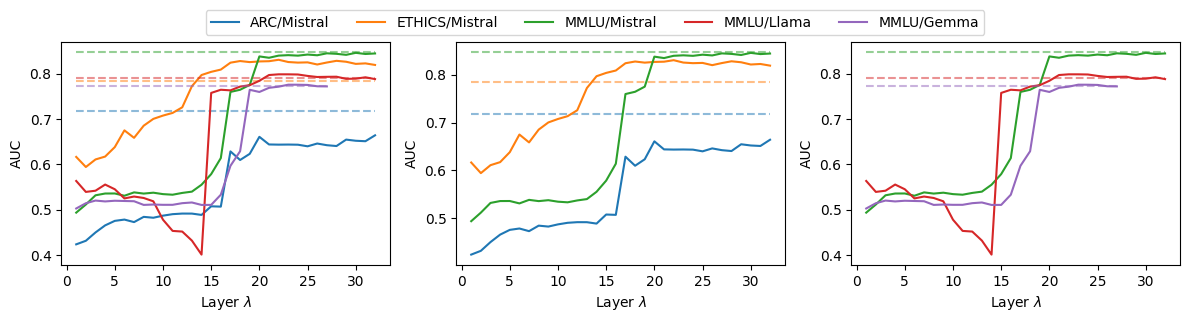

In [25]:
n_rows = 1
n_cols = 3

fig, (ax_all, ax_mist, ax_mmlu) = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

BEST_FOR_PSMI = {}
for idx_setup, setup in enumerate(setup_names):

    # Checkpoints
    chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
    chk_memo = checkpoints[setup][-1]

    # Predictors
    predictors = {
        layer: (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][layer][idx] for idx in global_idx[setup]],
            True,
        )
        for layer in cfg[setup].all_layers
    } | {
        "LOSS": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
    }

    # Iterating over predictors
    auc_at_layer = {}
    auc_loss = None
    for pred_name, (pred, reversed) in predictors.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][chk_memo][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Who is memorized ?
        memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
        memo_thd = np.quantile(memo, q=memo_prop_stat)
        is_memorized = [item >= memo_thd for item in memo]

        # Prec-rec curve
        fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)
        current_auc = auc(fpr, tpr)

        if type(pred_name) == int:
            auc_at_layer[pred_name] = current_auc
        elif "LOSS" in pred_name:
            auc_loss = current_auc
        else:
            raise ValueError(f"Unknow pred name: {pred_name}")
        
    layers = sorted(auc_at_layer.keys())
    values = [auc_at_layer[l] for l in layers]

    # Best ?
    BEST_FOR_PSMI[setup] = layers[np.argmax(values)]

    # Plotting - all
    ax_all.plot(layers, values, label=PRETTY_SETUP[setup], color=COLORS[idx_setup])
    ax_all.plot(layers, [auc_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup])

    # Plotting - mistral
    if "mis" in setup:
        ax_mist.plot(layers, values, color=COLORS[idx_setup])
        ax_mist.plot(layers, [auc_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup])

    # Plotting - mmlu
    if "mmlu" in setup:
        ax_mmlu.plot(layers, values, color=COLORS[idx_setup])
        ax_mmlu.plot(layers, [auc_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup])

# Plotting details
ax_all.set_xlabel(r'Layer $\lambda$')
ax_all.set_ylabel(f"AUC")
ax_mist.set_xlabel(r'Layer $\lambda$')
ax_mist.set_ylabel(f"AUC")
ax_mmlu.set_xlabel(r'Layer $\lambda$')
ax_mmlu.set_ylabel(f"AUC")

# ax_mist.set_ylim(0.04, 0.14)
# ax_mmlu.set_ylim(0.05, 0.11)

# Fig
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()

In [26]:
BEST_FOR_PSMI

{'arc__mis': 32,
 'ethi_mis': 22,
 'mmlu_mis': 30,
 'mmlu_lla': 22,
 'mmlu_gem': 23}

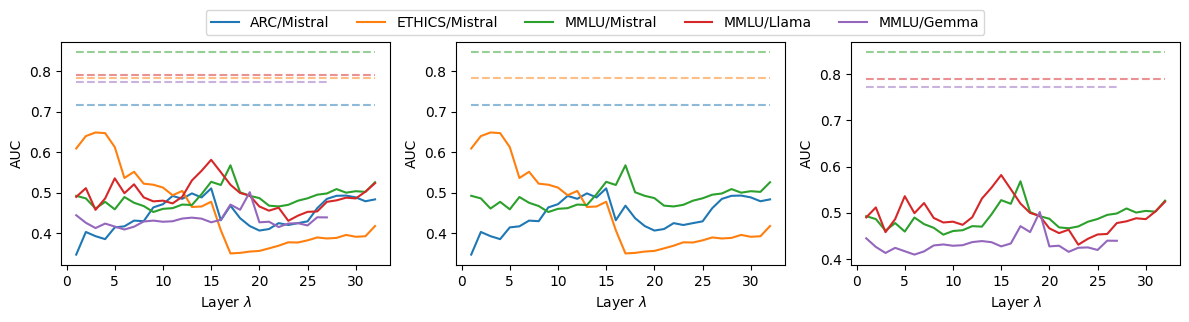

In [27]:
n_rows = 1
n_cols = 3

fig, (ax_all, ax_mist, ax_mmlu) = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

BEST_FOR_MAHD = {}
for idx_setup, setup in enumerate(setup_names):

    # Checkpoints
    chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
    chk_memo = checkpoints[setup][-1]

    # Predictors
    predictors = {
        layer: (
            [mahd_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][layer][idx] for idx in global_idx[setup]],
            True,
        )
        for layer in cfg[setup].all_layers
    } | {
        "LOSS": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
    }

    # Iterating over predictors
    auc_at_layer = {}
    auc_loss = None
    for pred_name, (pred, reversed) in predictors.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][chk_memo][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Who is memorized ?
        memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
        memo_thd = np.quantile(memo, q=memo_prop_stat)
        is_memorized = [item >= memo_thd for item in memo]

        # Prec-rec curve
        fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)
        current_auc = auc(fpr, tpr)

        if type(pred_name) == int:
            auc_at_layer[pred_name] = current_auc
        elif "LOSS" in pred_name:
            auc_loss = current_auc
        else:
            raise ValueError(f"Unknow pred name: {pred_name}")
        
    layers = sorted(auc_at_layer.keys())
    values = [auc_at_layer[l] for l in layers]

    # Best ?
    BEST_FOR_MAHD[setup] = layers[np.argmax(values)]

    # Plotting - all
    ax_all.plot(layers, values, label=PRETTY_SETUP[setup], color=COLORS[idx_setup])
    ax_all.plot(layers, [auc_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup])

    # Plotting - mistral
    if "mis" in setup:
        ax_mist.plot(layers, values, color=COLORS[idx_setup])
        ax_mist.plot(layers, [auc_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup])

    # Plotting - mmlu
    if "mmlu" in setup:
        ax_mmlu.plot(layers, values, color=COLORS[idx_setup])
        ax_mmlu.plot(layers, [auc_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup])

# Plotting details
ax_all.set_xlabel(r'Layer $\lambda$')
ax_all.set_ylabel(f"AUC")
ax_mist.set_xlabel(r'Layer $\lambda$')
ax_mist.set_ylabel(f"AUC")
ax_mmlu.set_xlabel(r'Layer $\lambda$')
ax_mmlu.set_ylabel(f"AUC")

# ax_mist.set_ylim(0.04, 0.14)
# ax_mmlu.set_ylim(0.05, 0.11)

# Fig
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()

In [28]:
BEST_FOR_MAHD

{'arc__mis': 15, 'ethi_mis': 3, 'mmlu_mis': 17, 'mmlu_lla': 15, 'mmlu_gem': 19}

## Teaser

0.21899539669645274 0.7807017543859649


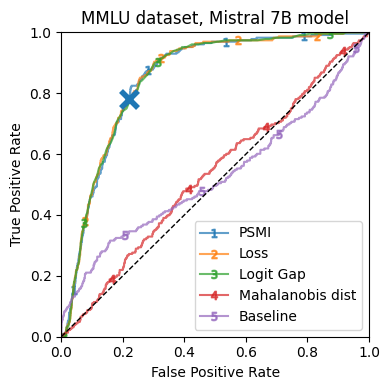

In [29]:
# local_colors = COLORS[3], COLORS[3], COLORS[0], COLORS[2], COLORS[1], COLORS[5], COLORS[4]
local_colors = COLORS

n_rows = 1
n_cols = 1
setup = "mmlu_mis"

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
predictors = {
    f"PSMI (default)": (
        [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][32][idx] for idx in global_idx[setup]],
        True,
    ),
    f"PSMI": (
        [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
        True,
    ),
    f"Loss": (
        [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        False,
    ),
    f"Logit Gap": (
        [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        True,
    ),
    f"Mahalanobis dist": (
        [mahd_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][13][idx] for idx in global_idx[setup]],
        False,
    ),
    f"Baseline": (
        [memo_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        False,
    ),
}

# Iterating over predictors
for idx_pred, (pred_name, (pred, reversed)) in enumerate(predictors.items()):
    memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] for idx in global_idx[setup]]
    if reversed:
        pred = [-1 * item for item in pred]
    
    # Sorting 
    sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
    nan_index = set([
        idx for idx in range(len(pred))
        if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
    ])
    memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
    pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

    # Who is memorized ?
    memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
    memo_thd = np.quantile(memo, q=memo_prop_stat)
    is_memorized = [item >= memo_thd for item in memo]

    # Prec-rec curve
    fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)
    current_auc = auc(fpr, tpr)

    # FPR @ 0.8 TPR
    for final_fpr, final_tpr, final_thd in zip(fpr, tpr, thd):
        if final_thd < 0:
            break
    
    if "default" in pred_name:
        ax.scatter(final_fpr, final_tpr, marker="x", label=None, s=150, linewidths=4, zorder=10, color=local_colors[idx_pred])
        print(final_fpr, final_tpr)
    else:
        ax.plot(fpr, tpr, label=f"{pred_name}", color=local_colors[idx_pred-1], alpha=.7, marker=MARKERS[idx_pred-1], markevery=markevery(len(fpr), idx_pred, 4, 6))

# Plot details
ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color="black")
# ax.plot([0, 1], [TPR_OBJ, TPR_OBJ], lw=1, linestyle='--', label="TPR objective", color="navy")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])

ax.set_title(f"MMLU dataset, Mistral 7B model")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")


ax.legend()
fig.tight_layout()

fig.savefig("teaser_perf.pdf")


## Figure 2: default hyperparameters

ethi_mis 0.4 0.23708592460972205 0.7213114754098361
ethi_mis 61 0.007682619647355163
arc__mis 0.2 0.24922118380062305 0.4594594594594595
arc__mis 37 0.037
mmlu_mis 0.2 0.21899539669645274 0.7807017543859649
mmlu_mis 228 0.0152
mmlu_lla 0.4 0.25792218210990775 0.6904761904761905
mmlu_lla 42 0.0028
mmlu_gem 0.2 0.20238095238095238 0.64
mmlu_gem 300 0.02
average None 0.2331211279195316 0.6583897759462902
average - no ARC None 0.2264328437291043 0.7037259816207184


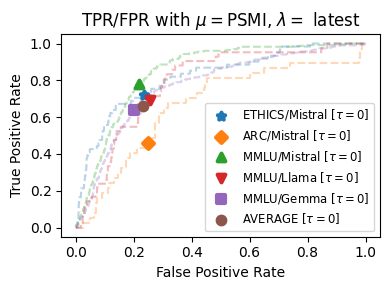

In [30]:
n_rows = 1
n_cols = 1

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
local_markers = ["*", "D", "^", "v", "s", "o"]

# Average
fpr_for_average = []
tpr_for_average = []

# Iterating over setups
for idx_setup, setup in enumerate(["ethi_mis", "arc__mis", "mmlu_mis", "mmlu_lla", "mmlu_gem"]):

    chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
    chk_memo = checkpoints[setup][-1]

    # Predictors
    predictors = {
        f"PSMI": (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][32 if "gem" not in setup else 27][idx] for idx in global_idx[setup]],
            True,
        ),
        f"PSMI-last": (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][32 if "gem" not in setup else 27][idx] for idx in global_idx[setup]],
            True,
        ),
    }

    # Iterating over predictors
    for pred_name, (pred, reversed) in predictors.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Who is memorized ?
        memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
        memo_thd = np.quantile(memo, q=memo_prop_stat)
        is_memorized = [item >= memo_thd for item in memo]

        # Prec-rec curve
        fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)

        # Easy predictor
        for final_fpr, final_tpr, final_thd in zip(fpr, tpr, thd):
            if final_thd < 0:
                break
        if "last" not in pred_name and "best" not in pred_name:
            ax.plot(fpr, tpr, color=COLORS[idx_setup], alpha=.3, linestyle="--")
        elif "last" in pred_name:
            fpr_for_average.append(final_fpr)
            tpr_for_average.append(final_tpr)
            ax.scatter(final_fpr, final_tpr, color=COLORS[idx_setup], label=f"{PRETTY_SETUP[setup]}" + r" [$\tau=0$]", marker=local_markers[idx_setup], s=30, linewidths=3, zorder=10)
            print(setup, checkpoint_to_epoch[setup][chk_pred], final_fpr, final_tpr)
            print(setup, sum(is_memorized), sum(is_memorized) / len(is_memorized))

# Scatter the average
ax.scatter(np.mean(fpr_for_average), np.mean(tpr_for_average), color=COLORS[5], label="AVERAGE"+ r" [$\tau=0$]", marker=local_markers[5], s=30, linewidths=3, zorder=10)
print("average", None, np.mean(fpr_for_average), np.mean(tpr_for_average))
print("average - no ARC", None, np.mean(fpr_for_average[:0] + fpr_for_average[2:]), np.mean(tpr_for_average[:0] + tpr_for_average[2:]))

ax.legend(ncol=1, loc="lower right", fontsize="small")
# ax.set_xlim(0, 0.25)
# ax.set_ylim(0.75, 1.0)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(r"TPR/FPR with $\mu = $PSMI, $\lambda = $ latest")

# Figure
# lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.25))
fig.tight_layout()
fig.savefig("perf_off_the_shelf.pdf")

## Figure 3: trade-off for another setting

PSMI [$\lambda$=23]: 0.7756624716553289
Loss: 0.772575850340136
Logit: 0.7681453514739229
Mahalanobis [$\lambda$=19]: 0.561265306122449
Baseline: 0.47468526077097506


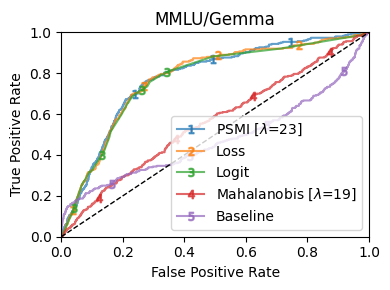

In [48]:
# local_colors = COLORS[3], COLORS[3], COLORS[0], COLORS[2], COLORS[1], COLORS[5], COLORS[4]
local_colors = COLORS

n_rows = 1
n_cols = 1
setup = "mmlu_gem"

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
predictors = {
    r"PSMI [$\lambda$=" + f"{BEST_FOR_PSMI[setup]}]": (
        [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
        True,
    ),
    f"Loss": (
        [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        False,
    ),
    f"Logit": (
        [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        True,
    ),
    r"Mahalanobis [$\lambda$=" + f"{BEST_FOR_MAHD[setup]}]": (
        [mahd_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][13][idx] for idx in global_idx[setup]],
        False,
    ),
    f"Baseline": (
        [memo_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        False,
    ),
}

# Iterating over predictors
for idx_pred, (pred_name, (pred, reversed)) in enumerate(predictors.items()):
    memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] for idx in global_idx[setup]]
    if reversed:
        pred = [-1 * item for item in pred]
    
    # Sorting 
    sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
    nan_index = set([
        idx for idx in range(len(pred))
        if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
    ])
    memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
    pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

    # Who is memorized ?
    memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
    memo_thd = np.quantile(memo, q=memo_prop_stat)
    is_memorized = [item >= memo_thd for item in memo]

    # Prec-rec curve
    fpr, tpr, _ = roc_curve(is_memorized, pred, drop_intermediate=False)
    current_auc = auc(fpr, tpr)
    print(f"{pred_name}: {current_auc}")

    ax.plot(fpr, tpr, label=f"{pred_name}", marker=MARKERS[idx_pred], markevery=markevery(len(tpr), idx_pred), alpha=.7)

# Plot details
ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color="black")
# ax.plot([0, 1], [TPR_OBJ, TPR_OBJ], lw=1, linestyle='--', label="TPR objective", color="navy")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])

ax.set_title(f"{PRETTY_SETUP[setup]}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")


ax.legend()
fig.tight_layout()

fig.savefig("perf_tpr_fpr.pdf")


## Figure 4: AUC perfs

In [32]:
HARD_MEMO_THD

4

arc__mis 0.037
ethi_mis 0.007682619647355163
mmlu_mis 0.0152
mmlu_lla 0.0028
mmlu_gem 0.02


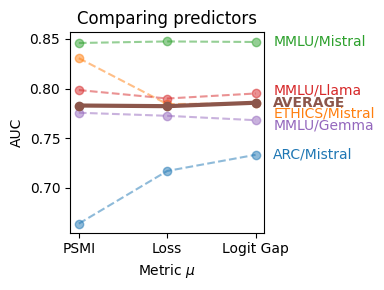

In [33]:
n_rows = 1
n_cols = 1

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

perf_per_setup = collections.defaultdict(list)

# Iterating over setups
for setup in setup_names:

    chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
    chk_memo = checkpoints[setup][-1]

    # Predictors
    predictors = {
        f"PSMI": (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
            True,
        ),
        f"Loss": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
        f"Logit Gap": (
            [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            True,
        ),
    }

    # Iterating over predictors
    for pred_name, (pred, reversed) in predictors.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Who is memorized ?
        memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
        memo_thd = np.quantile(memo, q=memo_prop_stat)
        is_memorized = [item >= memo_thd for item in memo]

        # Prec-rec curve
        fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)

        # Print
        if "PSMI" in pred_name:
            print(setup, sum(is_memorized) / len(is_memorized))

        # FPR @ 0.8 TPR
        # for final_fpr, final_tpr in zip(fpr, tpr):
        #     if final_tpr > TPR_OBJ:
        #         break

        # Saving
        perf_per_setup[setup].append(auc(fpr, tpr))

val_per_pred = collections.defaultdict(list)
# Mean per predictor
for setup in setup_names:
    for idx_pred, pred_name in enumerate(predictors):
        val_per_pred[pred_name].append(perf_per_setup[setup][idx_pred])

mean_per_pred = {}
for pred_name in val_per_pred:
    mean_per_pred[pred_name] = np.mean(val_per_pred[pred_name])

# Plotting
offset = [0, -0.01, 0, +0.003, -0.005, 0, 0]
global_offset = -0.004
for idx_setup, (setup, perfs) in enumerate(perf_per_setup.items()):
    ax.plot(range(len(predictors)), perfs, 'o--', label=PRETTY_SETUP[setup], alpha=.5)
    ax.text(2.2, perfs[-1] + global_offset + offset[idx_setup],PRETTY_SETUP[setup], color = COLORS[idx_setup])
ax.plot(range(len(predictors)), list(mean_per_pred.values()), 'o-', label="AVERAGE", alpha=1, linewidth=3, color=COLORS[len(setup_names)])
ax.text(2.2, list(mean_per_pred.values())[-1] + global_offset + offset[len(setup_names)], "AVERAGE", color = COLORS[len(setup_names)], fontweight="heavy")

ax.set_xticks(range(len(predictors)), list(predictors.keys()))
ax.set_xlabel(r"Metric $\mu$")
ax.set_ylabel(f"AUC")
ax.set_title(f"Comparing predictors")
# ax.legend()
fig.tight_layout()

fig.savefig("ablation_mu.pdf")


## Figure 5: dynamics

In [34]:
setup = "ethi_mis"

memo_samples = [idx for idx in global_idx[setup] if memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] >= HARD_MEMO_THD]
nomemo_samples = [idx for idx in global_idx[setup] if memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] < HARD_MEMO_THD]

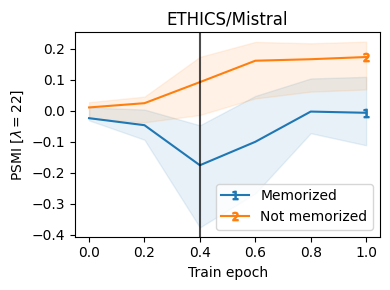

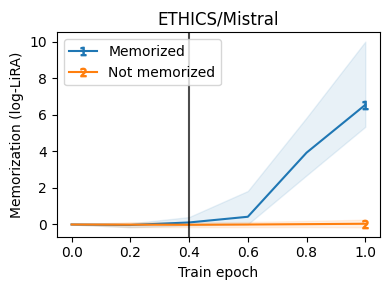

In [35]:
n_cols = 1
n_rows = 1

fig_psmi, ax_psmi = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
fig_memo, ax_memo = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
# fig_loss, ax_loss = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

all_losses_per_chk = collections.defaultdict(list)

for idx_container, (samples, title) in enumerate(zip([memo_samples, nomemo_samples], ["Memorized", "Not memorized"])):

    # Values
    epochs = []
    psmi_mean = []
    psmi_q25 = []
    psmi_q75 = []
    memo_mean = []
    memo_q25 = []
    memo_q75 = []
    loss_mean = []
    loss_q25 = []
    loss_q75 = []

    for chk in [0] + checkpoints[setup]:
        
        # Epoch
        epochs.append(checkpoint_to_epoch[setup][chk])

        # PSMI
        psmi = [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk][BEST_FOR_PSMI[setup]][idx] for idx in samples]
        psmi_mean.append(np.median(psmi))
        psmi_q25.append(np.quantile(psmi, q=0.25))
        psmi_q75.append(np.quantile(psmi, q=0.75))

        # Memo
        memo = [memo_per_setup_per_chk_per_idx[setup][chk][idx] for idx in samples]
        if chk == 0: # memorization is np.nan for checkpoint 0, but it should be zero
            memo = [0 for idx in samples]
        memo_mean.append(np.median(memo))
        memo_q25.append(np.quantile(memo, q=0.25))
        memo_q75.append(np.quantile(memo, q=0.75))

    # Plotting
    ax_psmi.plot(epochs, psmi_mean, color=COLORS[idx_container], label=title, marker=MARKERS[idx_container], markevery=(5, 1))
    ax_psmi.fill_between(epochs, psmi_q25, psmi_q75, alpha=.1, color=COLORS[idx_container])

    ax_memo.plot(epochs, memo_mean, color=COLORS[idx_container], label=title, marker=MARKERS[idx_container], markevery=(5, 1))
    ax_memo.fill_between(epochs, memo_q25, memo_q75, alpha=.1, color=COLORS[idx_container])
    
ax_psmi.set_title(f"{PRETTY_SETUP[setup]}")
ax_memo.set_title(f"{PRETTY_SETUP[setup]}")
# ax_loss.set_title("Loss median and 25-75% quantiles")

ax_psmi.set_xlabel("Train epoch")
ax_memo.set_xlabel("Train epoch")
# ax_loss.set_xlabel("Train epoch")

# print(f"Easy low loss epoch = {checkpoints[low_loss_idx]/STEP_PER_EPOCH}")
# print(f"Min test loss = {perf_df['epoch'][idx_min_test_loss]}")
# print(f"Max test acc = {perf_df['epoch'][idx_max_acc_loss]}")

ax_psmi.axvline(0.4, color="black", linestyle="-", alpha=.7)
ax_memo.axvline(0.4, color="black", linestyle="-", alpha=.7)

# FIgures
ax_psmi.legend(loc=4)
ax_psmi.set_ylabel(r"PSMI [$\lambda=$" + f"{BEST_FOR_PSMI[setup]}]")
fig_psmi.tight_layout()
fig_psmi.savefig("ablation_rho_psmi.pdf")

ax_memo.legend(loc=2)
ax_memo.set_ylabel(f"Memorization (log-LiRA)")
fig_memo.tight_layout()
fig_memo.savefig("ablation_rho_memo.pdf")

## Timing of the measures

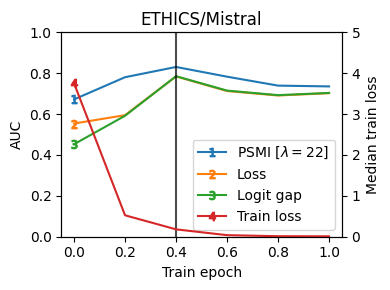

In [36]:
n_rows = 1
n_cols = 1
setup = "ethi_mis"

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

fpr_at_per_pred = collections.defaultdict(list)
chk_to_pred = [0] + checkpoints[setup][0:5]
pred_median_per_chk = collections.defaultdict(list)
for chk_pred in chk_to_pred:

    # Predictors
    predictors = {
        f"PSMI": (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
            True,
        ),
        "Loss": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
        "Logit": (
            [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            True,
        ),
    }

    # Iterating over predictors
    for pred_name, (pred, reversed) in predictors.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Median
        pred_median_per_chk[pred_name].append(
            np.median(pred) if not reversed else -1 * np.median(pred)
        )

        # Who is memorized ?
        memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
        memo_thd = np.quantile(memo, q=memo_prop_stat)
        is_memorized = [item >= memo_thd for item in memo]

        # Prec-rec curve
        fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)

        # FPR @ 0.8 TPR
        # for final_fpr, final_tpr in zip(fpr, tpr):
        #     if final_tpr > TPR_OBJ:
        #         break

        fpr_at_per_pred[pred_name].append(auc(fpr, tpr))

# When did the median loss cross

# The real PSMI and loss perf
ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"PSMI"], label=r"PSMI [$\lambda=$" + f"{BEST_FOR_PSMI[setup]}]", color=COLORS[0], marker=MARKERS[0], markevery=6)
ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"Loss"], label=f"Loss", color=COLORS[1], marker=MARKERS[1], markevery=6)
ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"Logit"], label=f"Logit gap", color=COLORS[2], marker=MARKERS[2], markevery=6)
# A fake PSMI under the other for the legend of the loss
ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], [-1 for _ in fpr_at_per_pred[f"PSMI"]], label=f"Train loss", color=COLORS[3], zorder=-1, marker=MARKERS[3], markevery=6)
# The real loss
ax_loss = ax.twinx()
ax_loss.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], pred_median_per_chk["Loss"], color = COLORS[3], marker=MARKERS[3], markevery=6)
# The vline
ax.axvline(0.4, color="black", linestyle="-", alpha=.7)

# Plot details
ax.set_title(f"{PRETTY_SETUP[setup]}")
ax.set_xlabel("Train epoch")
ax.set_ylabel(f"AUC")
ax.set_ylim(0, 1)
ax_loss.set_ylim(0, 5)
ax_loss.set_ylabel("Median train loss")
ax.legend()

fig.tight_layout()

fig.savefig("ablation_rho_perf.pdf")

## Teaser: timing of the measure

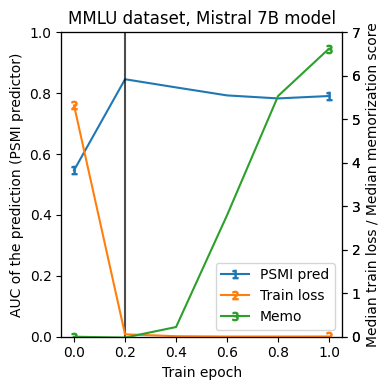

In [37]:
n_rows = 1
n_cols = 1
setup = "mmlu_mis"

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

memo_samples = [idx for idx in global_idx[setup] if memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] >= HARD_MEMO_THD]
nomemo_samples = [idx for idx in global_idx[setup] if memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] < HARD_MEMO_THD]

fpr_at_per_pred = collections.defaultdict(list)
chk_to_pred = [0] + checkpoints[setup][0:5]
pred_median_per_chk = collections.defaultdict(list)
memo_median_per_chk = []
for chk_pred in chk_to_pred:

    # Predictors
    predictors = {
        f"PSMI": (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
            True,
        ),
        "Loss": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
        "Logit": (
            [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            True,
        ),
    }

    # Iterating over predictors
    for pred_name, (pred, reversed) in predictors.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Median
        pred_median_per_chk[pred_name].append(
            np.median(pred) if not reversed else -1 * np.median(pred)
        )

        # Who is memorized ?
        memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
        memo_thd = np.quantile(memo, q=memo_prop_stat)
        is_memorized = [item >= memo_thd for item in memo]

        # Prec-rec curve
        fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)

        # FPR @ 0.8 TPR
        # for final_fpr, final_tpr in zip(fpr, tpr):
        #     if final_tpr > TPR_OBJ:
        #         break

        fpr_at_per_pred[pred_name].append(auc(fpr, tpr))

    # Memorization plot
    if chk_pred == 0:
        memo_median_per_chk.append(0)
    else:
        current_memo_of_memorized_samples = [memo_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in memo_samples]
        memo_median_per_chk.append(np.median(current_memo_of_memorized_samples))

# The real PSMI and loss perf
ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"PSMI"], label=f"PSMI pred", color=COLORS[0], marker=MARKERS[0], markevery=(0,5))
# ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"Loss"], label=f"Loss perf", color=COLORS[1])
# ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"Logit"], label=f"Logit gap perf", color=COLORS[2])
# A fake PSMI under the other for the legend of the loss
# A second fake PSMI under the other for the legend of memorization
ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], [-1 for _ in fpr_at_per_pred[f"PSMI"]], label=f"Train loss", color=COLORS[1], marker=MARKERS[1], zorder=-1)
ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], [-1 for _ in fpr_at_per_pred[f"PSMI"]], label=f"Memo", color=COLORS[2], marker=MARKERS[2], zorder=-2)

# The real loss
ax_loss = ax.twinx()
ax_loss.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], pred_median_per_chk["Loss"], color = COLORS[1], marker=MARKERS[1], markevery=(0,5))

# The memorization plot
ax_memo = ax.twinx()
ax_memo.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], memo_median_per_chk, color=COLORS[2], marker=MARKERS[2], markevery=(0,5))

# The vline
ax.axvline(0.2, color="black", linestyle="-", alpha=.7)

# Plot details
ax.set_title(f"MMLU dataset, Mistral 7B model")
ax.set_xlabel("Train epoch")
ax.set_ylabel(f"AUC of the prediction (PSMI predictor)")
ax.set_ylim(0, 1)
ax_loss.set_ylim(0, 7)
ax_memo.set_ylim(0, 7)
ax_loss.set_ylabel("Median train loss / Median memorization score")
ax.legend(loc="lower right")

fig.tight_layout()

fig.savefig("teaser_timing.pdf")

## Condensed quantiles

In [38]:
setup = "mmlu_lla"

# memo_quantiles = np.logspace(np.log10(0.001), np.log10(0.2), endpoint=True, base=10, num=50)
memo_thresholds = np.linspace(1, 10, endpoint=True, num=50)

0.0028
0.0028
0.0028


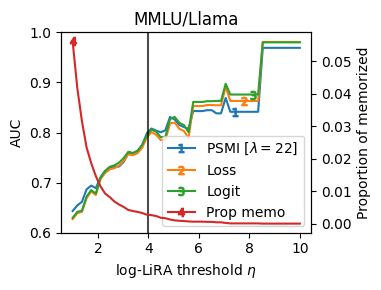

In [39]:
n_rows = 1
n_cols = 1

fig, ax = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

ax_prop = ax.twinx()

# Checkpoints
chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
chk_memo = checkpoints[setup][-1]

# Predictors
predictors = {
    r"PSMI [$\lambda=$" + f"{BEST_FOR_PSMI[setup]}]": (
        [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
        True,
    ),
    "Loss": (
        [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        False,
    ),
    "Logit": (
        [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
        True,
    ),
}

# Iterating over predictors
for idx_pred, (pred_name, (pred, reversed)) in enumerate(predictors.items()):
    memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
    if reversed:
        pred = [-1 * item for item in pred]
    
    # Sorting 
    sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
    nan_index = set([
        idx for idx in range(len(pred))
        if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
    ])
    memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
    pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

    # Who is memorized ?
    quantile_hard_thd = sum(np.array(memo) >= HARD_MEMO_THD) / len(memo)
    print(quantile_hard_thd)
    fpr_at = []
    prop_memo = []
    for memo_thd in memo_thresholds:

        # memo_thd = np.quantile(memo, q=1-q)
        is_memorized = [item >= memo_thd for item in memo]

        # Prec-rec curve
        fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)
        fpr_at.append(auc(fpr, tpr))
        prop_memo.append(sum(is_memorized) / len(is_memorized))

    # Plotting
    ax.plot(memo_thresholds, fpr_at, label=f"{pred_name}", marker=MARKERS[idx_pred], markevery=(35 + 2*idx_pred, len(fpr_at)))
    if "Logit" in pred_name:
        ax_prop.plot(memo_thresholds, prop_memo, color=COLORS[3], marker=MARKERS[3], markevery=(0, len(prop_memo)))

        # Fake PSMI to add a label
        ax.plot(memo_thresholds, [-1 for _ in memo_thresholds], label=f"Prop memo", color=COLORS[3], zorder=-1, marker=MARKERS[3])

# Vline for hard threshold
ax.axvline(4, label=None, color="black", alpha=.7)

# Plotting details
ax.legend()
# ax.set_xscale("log")
ax.set_xlabel(r"log-LiRA threshold $\eta$")
ax.set_ylabel(f"AUC")
ax_prop.set_ylabel("Proportion of memorized")
ax.set_title(f"{PRETTY_SETUP[setup]}")
ax.set_ylim(0.6, 1)

# Figure
fig.tight_layout()
fig.savefig("ablation_eta.pdf")

## Appendix: timing of the measure

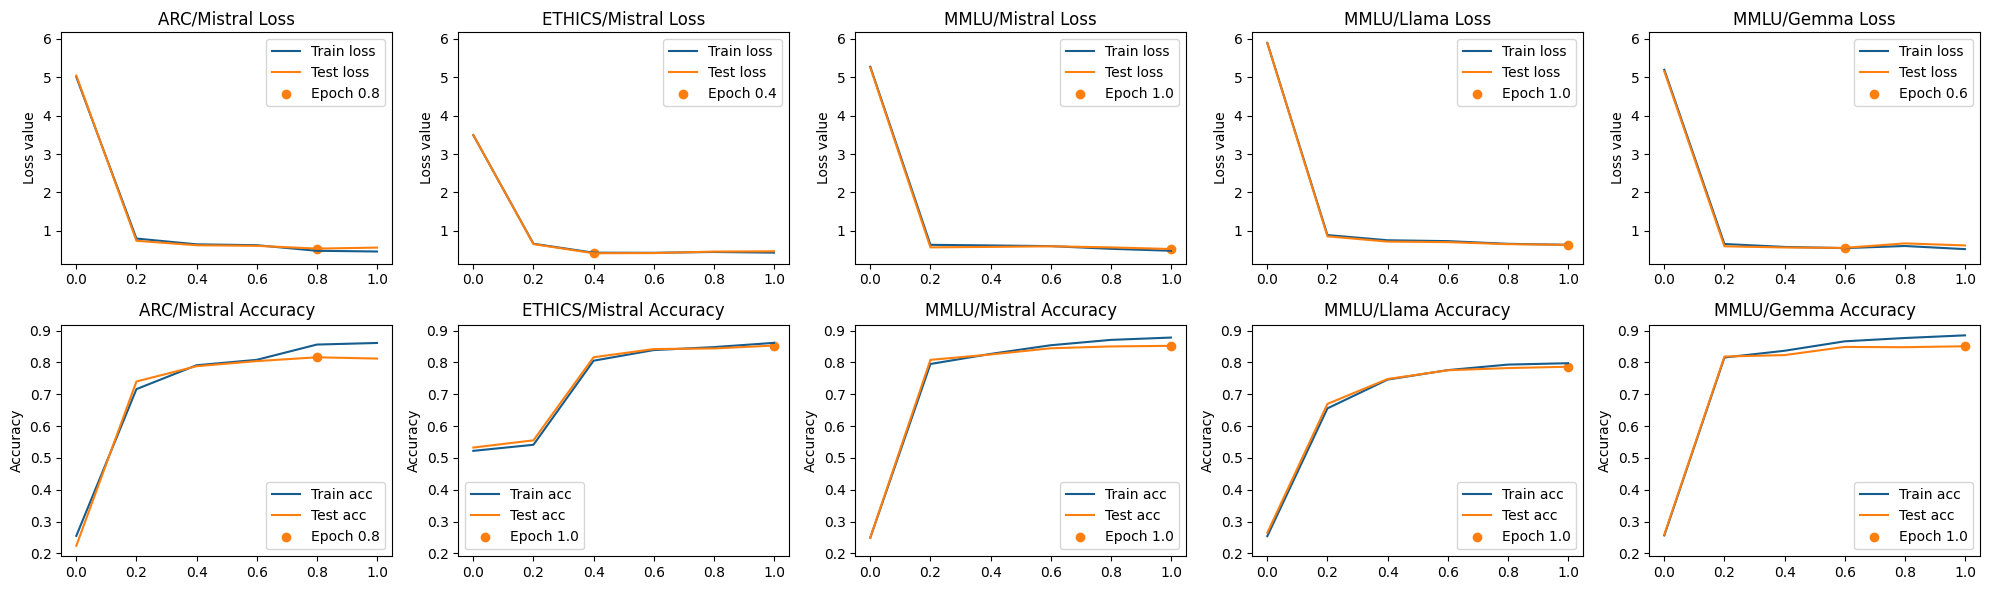

In [40]:
n_cols = len(setup_names)
n_rows = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows)) 

for idx_col, setup in enumerate(setup_names):

    # ====================== Loss ======================
    ax = axs[0, idx_col]
    ax.plot(perf_df_per_setup[setup]["epoch"], perf_df_per_setup[setup]["train_all_loss_asw"], label="Train loss", color=BW_COLORS_2[0])
    ax.plot(perf_df_per_setup[setup]["epoch"], perf_df_per_setup[setup]["test_loss_asw"], label="Test loss", color=BW_COLORS_2[1])
    
    # Scatter
    test_losses = perf_df_per_setup[setup]["test_loss_asw"]
    plot_checkpoints = perf_df_per_setup[setup]["epoch"]
    min_loss, min_loss_epoch = min(test_losses), plot_checkpoints[np.argmin(test_losses)]
    ax.scatter(min_loss_epoch, min_loss, color=BW_COLORS_2[1], label=f"Epoch {min_loss_epoch}")
    
    ax.legend()
    ax.set_title(f"{PRETTY_SETUP[setup]} Loss")
    ax.set_ylabel("Loss value")

    # Share y ?
    if idx_col > 0:
        ax.sharey(axs[0, 0])

    # ====================== Accuracy ======================
    ax = axs[1, idx_col]
    ax.plot(perf_df_per_setup[setup]["epoch"], perf_df_per_setup[setup]["train_all_accuracy"], label="Train acc", color=BW_COLORS_2[0])
    ax.plot(perf_df_per_setup[setup]["epoch"], perf_df_per_setup[setup]["test_accuracy"], label="Test acc", color=BW_COLORS_2[1])

    # Scatter
    test_accuracies = perf_df_per_setup[setup]["test_accuracy"]
    plot_checkpoints = perf_df_per_setup[setup]["epoch"]
    max_acc, max_acc_epoch = max(test_accuracies), plot_checkpoints[np.argmax(test_accuracies)]
    ax.scatter(max_acc_epoch, max_acc, color=BW_COLORS_2[1], label=f"Epoch {max_acc_epoch}")

    ax.legend()
    ax.set_title(f"{PRETTY_SETUP[setup]} Accuracy")
    ax.set_ylabel("Accuracy")

    # Share y ?
    if idx_col > 0:
        ax.sharey(axs[1, 0])

fig.tight_layout()
fig.savefig("appendix_rho_training_facts.pdf")

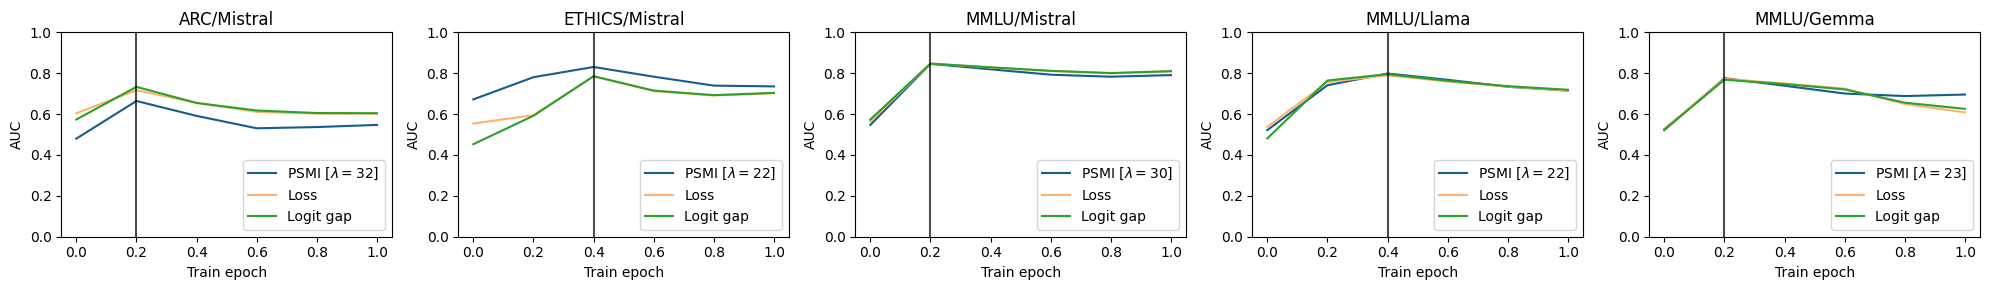

In [41]:
n_cols = len(setup_names)
n_rows = 1

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

for idx_col, setup in enumerate(setup_names):

    # Axes 
    ax = axs[idx_col]

    fpr_at_per_pred = collections.defaultdict(list)
    chk_to_pred = [0] + checkpoints[setup][0:5]
    pred_median_per_chk = collections.defaultdict(list)
    for chk_pred in chk_to_pred:

        # Predictors
        predictors = {
            f"PSMI": (
                [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
                True,
            ),
            "Loss": (
                [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
                False,
            ),
            "Logit": (
                [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
                True,
            ),
        }

        # Iterating over predictors
        for pred_name, (pred, reversed) in predictors.items():
            memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
            if reversed:
                pred = [-1 * item for item in pred]
            
            # Sorting 
            sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
            nan_index = set([
                idx for idx in range(len(pred))
                if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
            ])
            memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
            pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

            # Median
            pred_median_per_chk[pred_name].append(
                np.median(pred) if not reversed else -1 * np.median(pred)
            )

            # Who is memorized ?
            memo_prop_stat = 1 - np.mean(np.array(memo) >= HARD_MEMO_THD)
            memo_thd = np.quantile(memo, q=memo_prop_stat)
            is_memorized = [item >= memo_thd for item in memo]

            # Prec-rec curve
            fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)

            # FPR @ 0.8 TPR
            # for final_fpr, final_tpr in zip(fpr, tpr):
            #     if final_tpr > TPR_OBJ:
            #         break

            fpr_at_per_pred[pred_name].append(auc(fpr, tpr))

    # When did the median loss cross

    # The real PSMI and loss perf
    ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"PSMI"], label=r"PSMI [$\lambda=$" + f"{BEST_FOR_PSMI[setup]}]", color=BW_COLORS_3[0])
    ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"Loss"], label=f"Loss", color=BW_COLORS_3[1])
    ax.plot([checkpoint_to_epoch[setup][chk] for chk in chk_to_pred], fpr_at_per_pred[f"Logit"], label=f"Logit gap", color=BW_COLORS_3[2])

    # The vline
    ax.axvline(checkpoint_to_epoch[setup][checkpoints[setup][SETUP_TO_PRED_IDX[setup]]], color="black", linestyle="-", alpha=.7)

    # Plot details
    ax.set_title(f"{PRETTY_SETUP[setup]}")
    ax.set_xlabel("Train epoch")
    ax.set_ylabel(f"AUC")
    ax.set_ylim(0, 1)
    ax_loss.set_ylim(0, 5)
    ax_loss.set_ylabel("Median train loss")
    ax.legend(loc=4)

fig.tight_layout()
fig.savefig("appendix_rho_auc_dynamics.pdf")


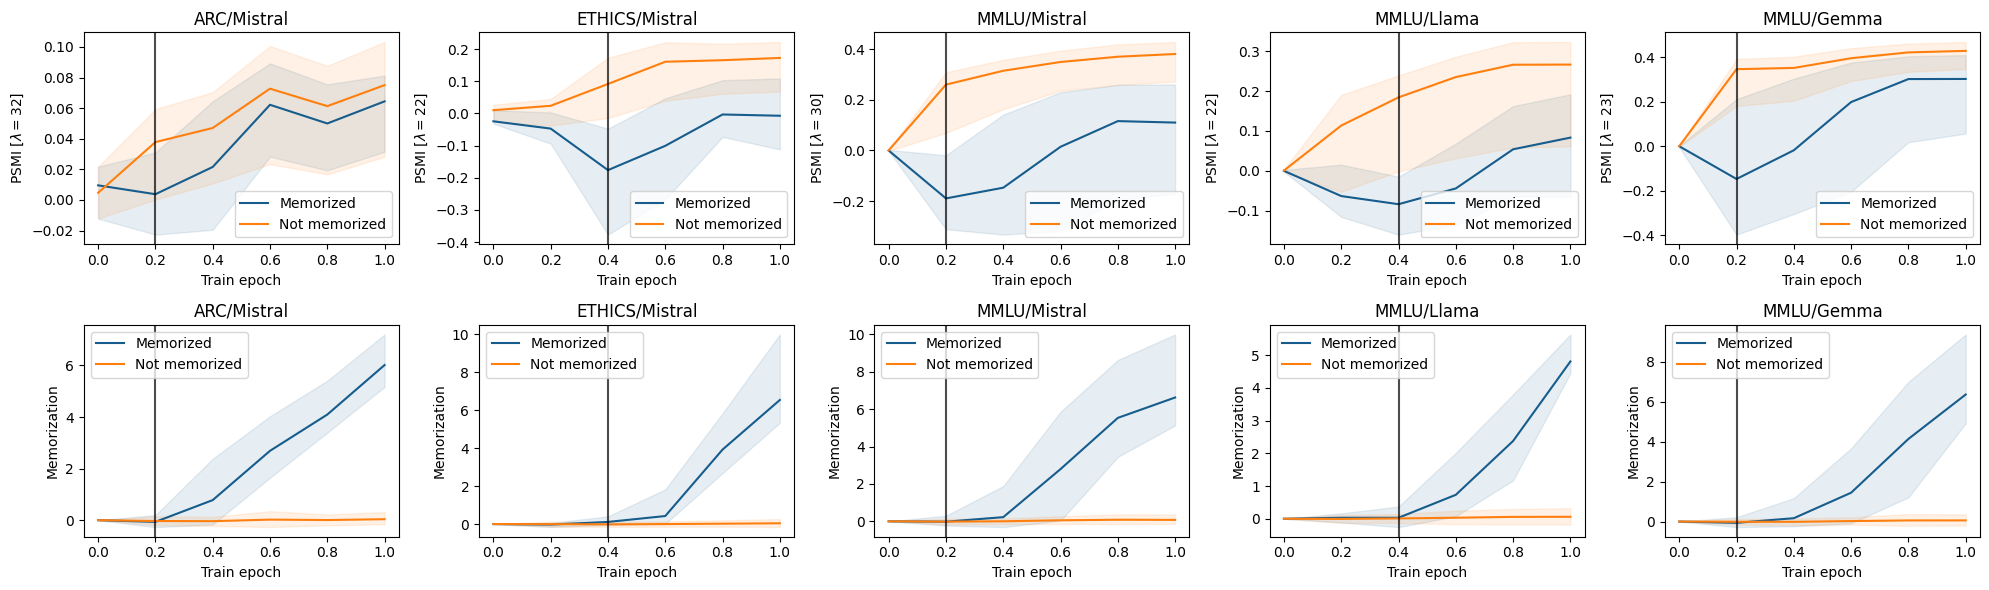

In [42]:
n_cols = len(setup_names)
n_rows = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

for idx_col, setup in enumerate(setup_names):

    # Axes 
    ax_psmi = axs[0, idx_col]
    ax_memo = axs[1, idx_col]

    all_losses_per_chk = collections.defaultdict(list)

    # Memo / Not memo
    memo_samples = [idx for idx in global_idx[setup] if memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] >= HARD_MEMO_THD]
    nomemo_samples = [idx for idx in global_idx[setup] if memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][-1]][idx] < HARD_MEMO_THD]

    for idx_container, (samples, title) in enumerate(zip([memo_samples, nomemo_samples], ["Memorized", "Not memorized"])):

        # Values
        epochs = []
        psmi_mean = []
        psmi_q25 = []
        psmi_q75 = []
        memo_mean = []
        memo_q25 = []
        memo_q75 = []
        loss_mean = []
        loss_q25 = []
        loss_q75 = []

        for chk in [0] + checkpoints[setup]:
            
            # Epoch
            epochs.append(checkpoint_to_epoch[setup][chk])

            # PSMI
            psmi = [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk][BEST_FOR_PSMI[setup]][idx] for idx in samples]
            psmi_mean.append(np.median(psmi))
            psmi_q25.append(np.quantile(psmi, q=0.25))
            psmi_q75.append(np.quantile(psmi, q=0.75))

            # Memo
            memo = [memo_per_setup_per_chk_per_idx[setup][chk][idx] for idx in samples]
            if chk == 0: # memorization is np.nan for checkpoint 0, but it should be zero
                memo = [0 for _ in samples]
            memo_mean.append(np.median(memo))
            memo_q25.append(np.quantile(memo, q=0.25))
            memo_q75.append(np.quantile(memo, q=0.75))

        # Plotting
        ax_psmi.plot(epochs, psmi_mean, color=BW_COLORS_2[idx_container], label=title)
        ax_psmi.fill_between(epochs, psmi_q25, psmi_q75, alpha=.1, color=BW_COLORS_2[idx_container])

        ax_memo.plot(epochs, memo_mean, color=BW_COLORS_2[idx_container], label=title)
        ax_memo.fill_between(epochs, memo_q25, memo_q75, alpha=.1, color=BW_COLORS_2[idx_container])
        
    ax_psmi.set_title(f"{PRETTY_SETUP[setup]}")
    ax_memo.set_title(f"{PRETTY_SETUP[setup]}")

    ax_psmi.set_xlabel("Train epoch")
    ax_memo.set_xlabel("Train epoch")

    ax_psmi.axvline(checkpoint_to_epoch[setup][checkpoints[setup][SETUP_TO_PRED_IDX[setup]]], color="black", linestyle="-", alpha=.7)
    ax_memo.axvline(checkpoint_to_epoch[setup][checkpoints[setup][SETUP_TO_PRED_IDX[setup]]], color="black", linestyle="-", alpha=.7)

    # Figures
    ax_psmi.legend(loc=4)
    ax_psmi.set_ylabel(r"PSMI [$\lambda=$" + f"{BEST_FOR_PSMI[setup]}]")

    ax_memo.legend(loc=2)
    ax_memo.set_ylabel(f"Memorization")

# Figure
fig.tight_layout()
fig.savefig("appendix_rho_psmi_memo_dynamics.pdf")

## Appendix: TPR/FPR curve

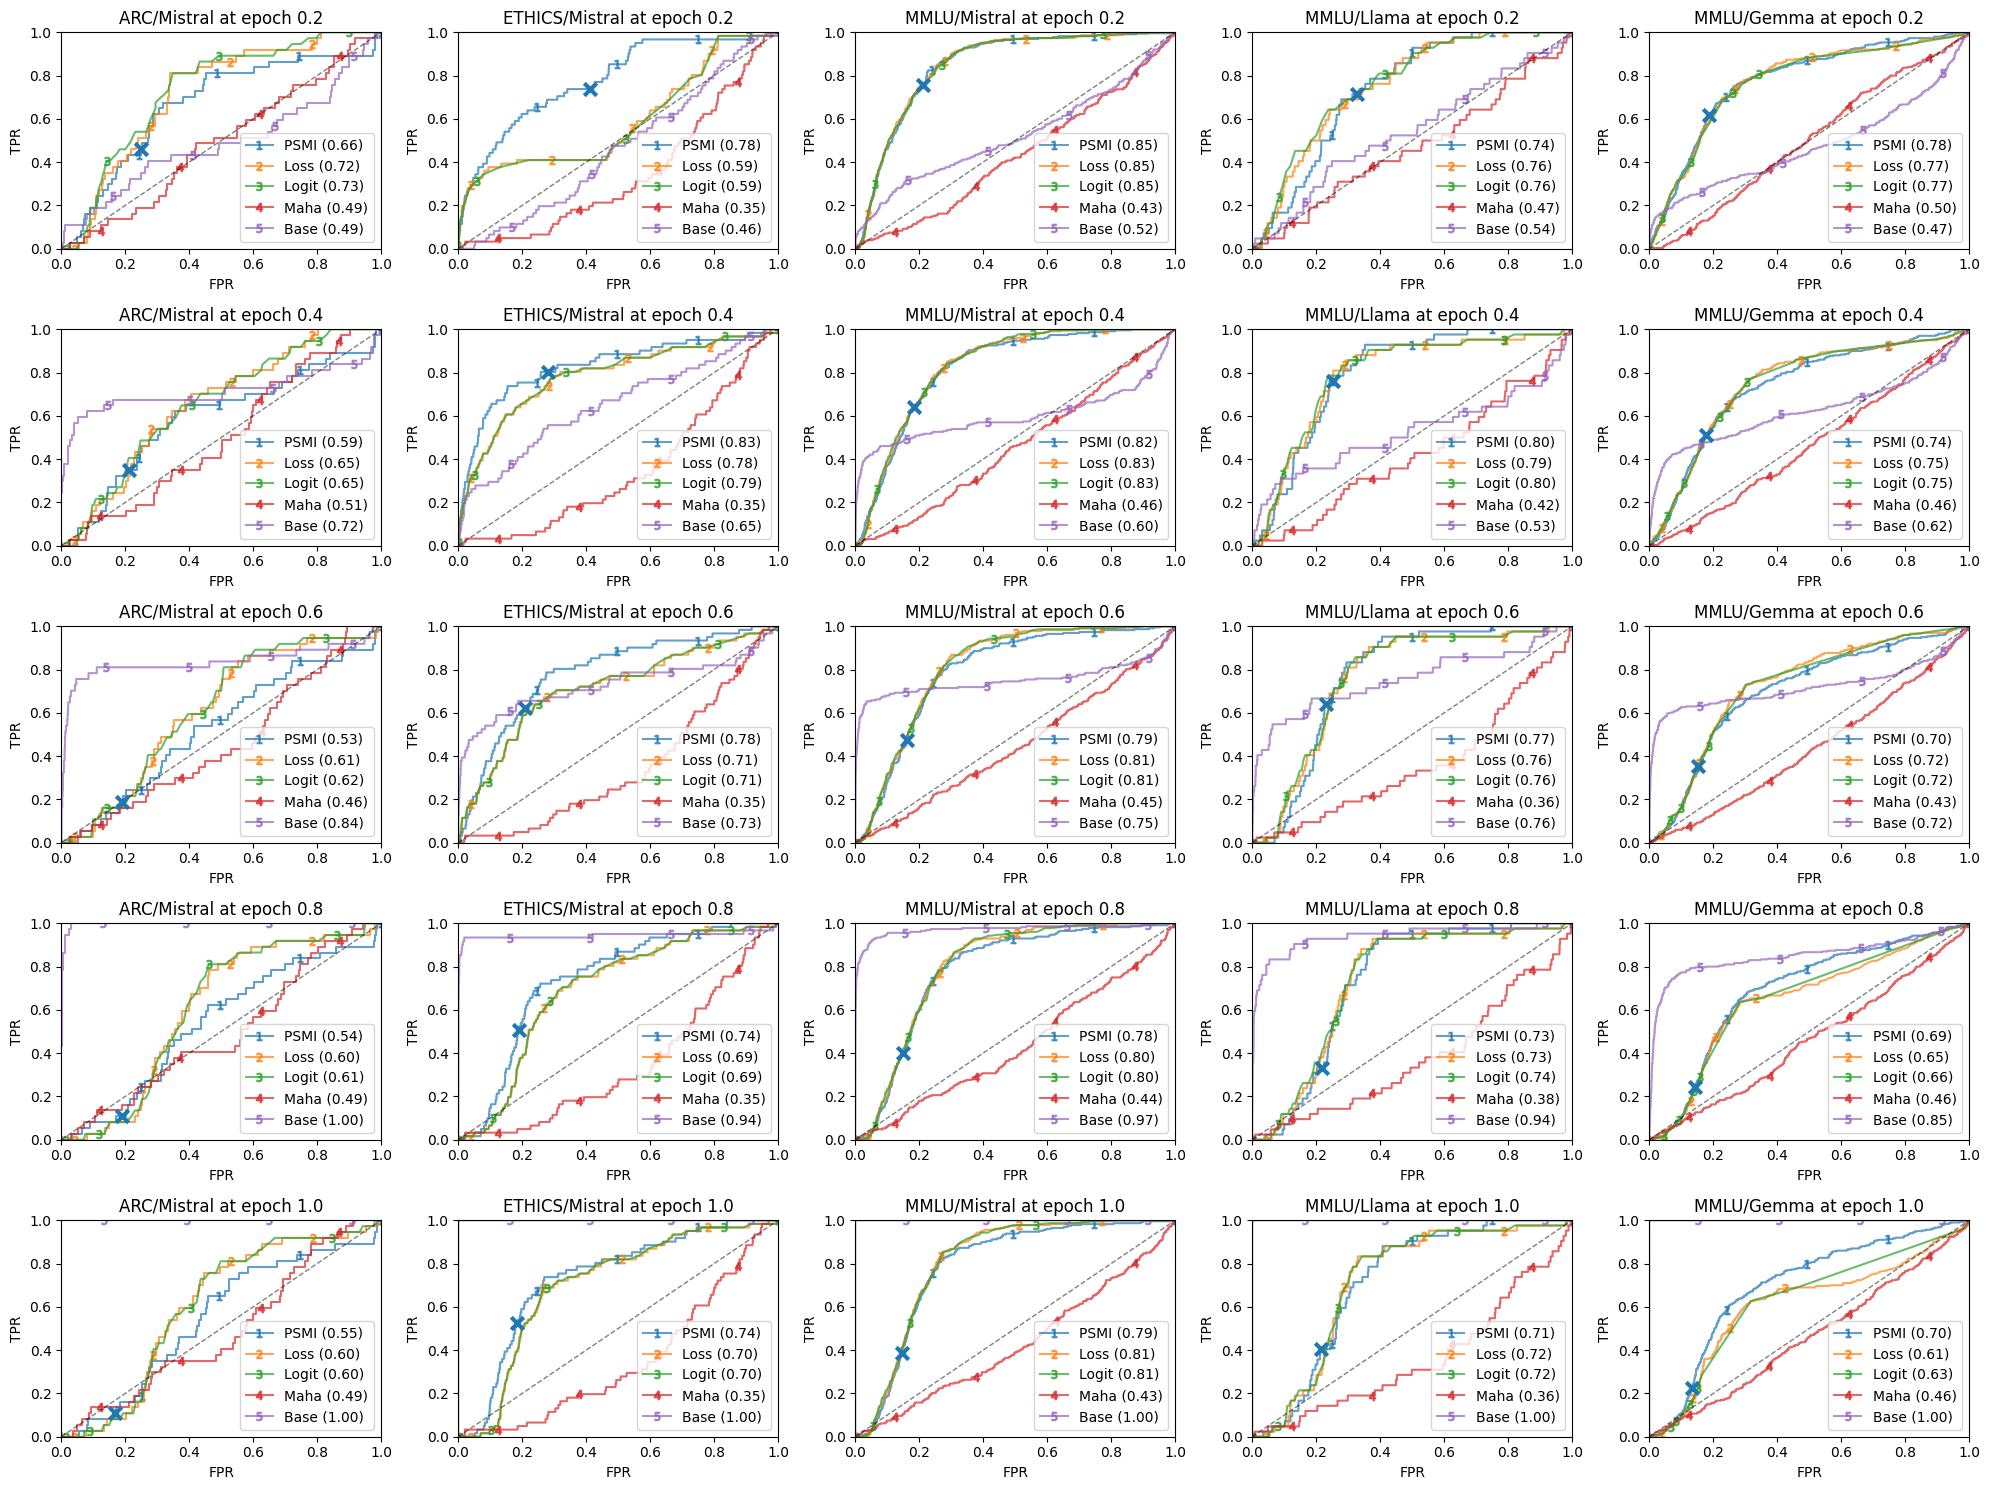

In [43]:
n_rows = 5
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

for idx_col, setup in enumerate(setup_names):
    for idx_row, INDEX_PRED in enumerate(range(n_rows)):
        ax = axes[idx_row, idx_col]

        chk_pred = checkpoints[setup][INDEX_PRED]
        predictors = {
            f"PSMI": (
                [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
                True,
            ),
            "Loss": (
                [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
                False,
            ),
            f"Logit": (
                [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
                True,
            ),
            f"Maha": (
                [mahd_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_MAHD[setup]][idx] for idx in global_idx[setup]],
                False,
            ),
            f"Base": (
                [memo_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
                False,
            ),
        }

        # Iterating over predictors
        for idx_pred, (pred_name, (pred, reversed)) in enumerate(predictors.items()):
            memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
            if reversed:
                pred = [-1 * item for item in pred]
            
            # Sorting 
            sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
            nan_index = set([
                idx for idx in range(len(pred))
                if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
            ])
            memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
            pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

            # Who is memorized ?
            is_memorized = [item >= HARD_MEMO_THD for item in memo]

            # Prec-rec curve
            fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)
            current_auc = auc(fpr, tpr)

            for final_fpr, final_tpr, final_thd in zip(fpr, tpr, thd):
                if final_thd < 0:
                    break

            if "PSMI" in pred_name:
                ax.scatter(final_fpr, final_tpr, color=COLORS[0], marker="x", s=80, linewidths=3, zorder=10)

            label = f"{pred_name} ({current_auc:.2f})"
            ax.plot(fpr, tpr, label=label, marker=MARKERS[idx_pred], markevery=markevery(len(tpr), idx_pred), alpha=.7)

        # Plot details
        ax.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', alpha=.5)
        # ax.plot([0, 1], [TPR_OBJ, TPR_OBJ], color='navy', lw=1, linestyle='--')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.0])

        ax.set_title(f"{PRETTY_SETUP[setup]} at epoch {checkpoint_to_epoch[setup][chk_pred]}")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")


        ax.legend()

# Figures
fig.tight_layout()
fig.savefig("appendix_mu_full_auc_curves.pdf")



## Appendix: histograms of memorization

In [44]:
BINS = 100
MIN_X = -5
MAX_X = 5

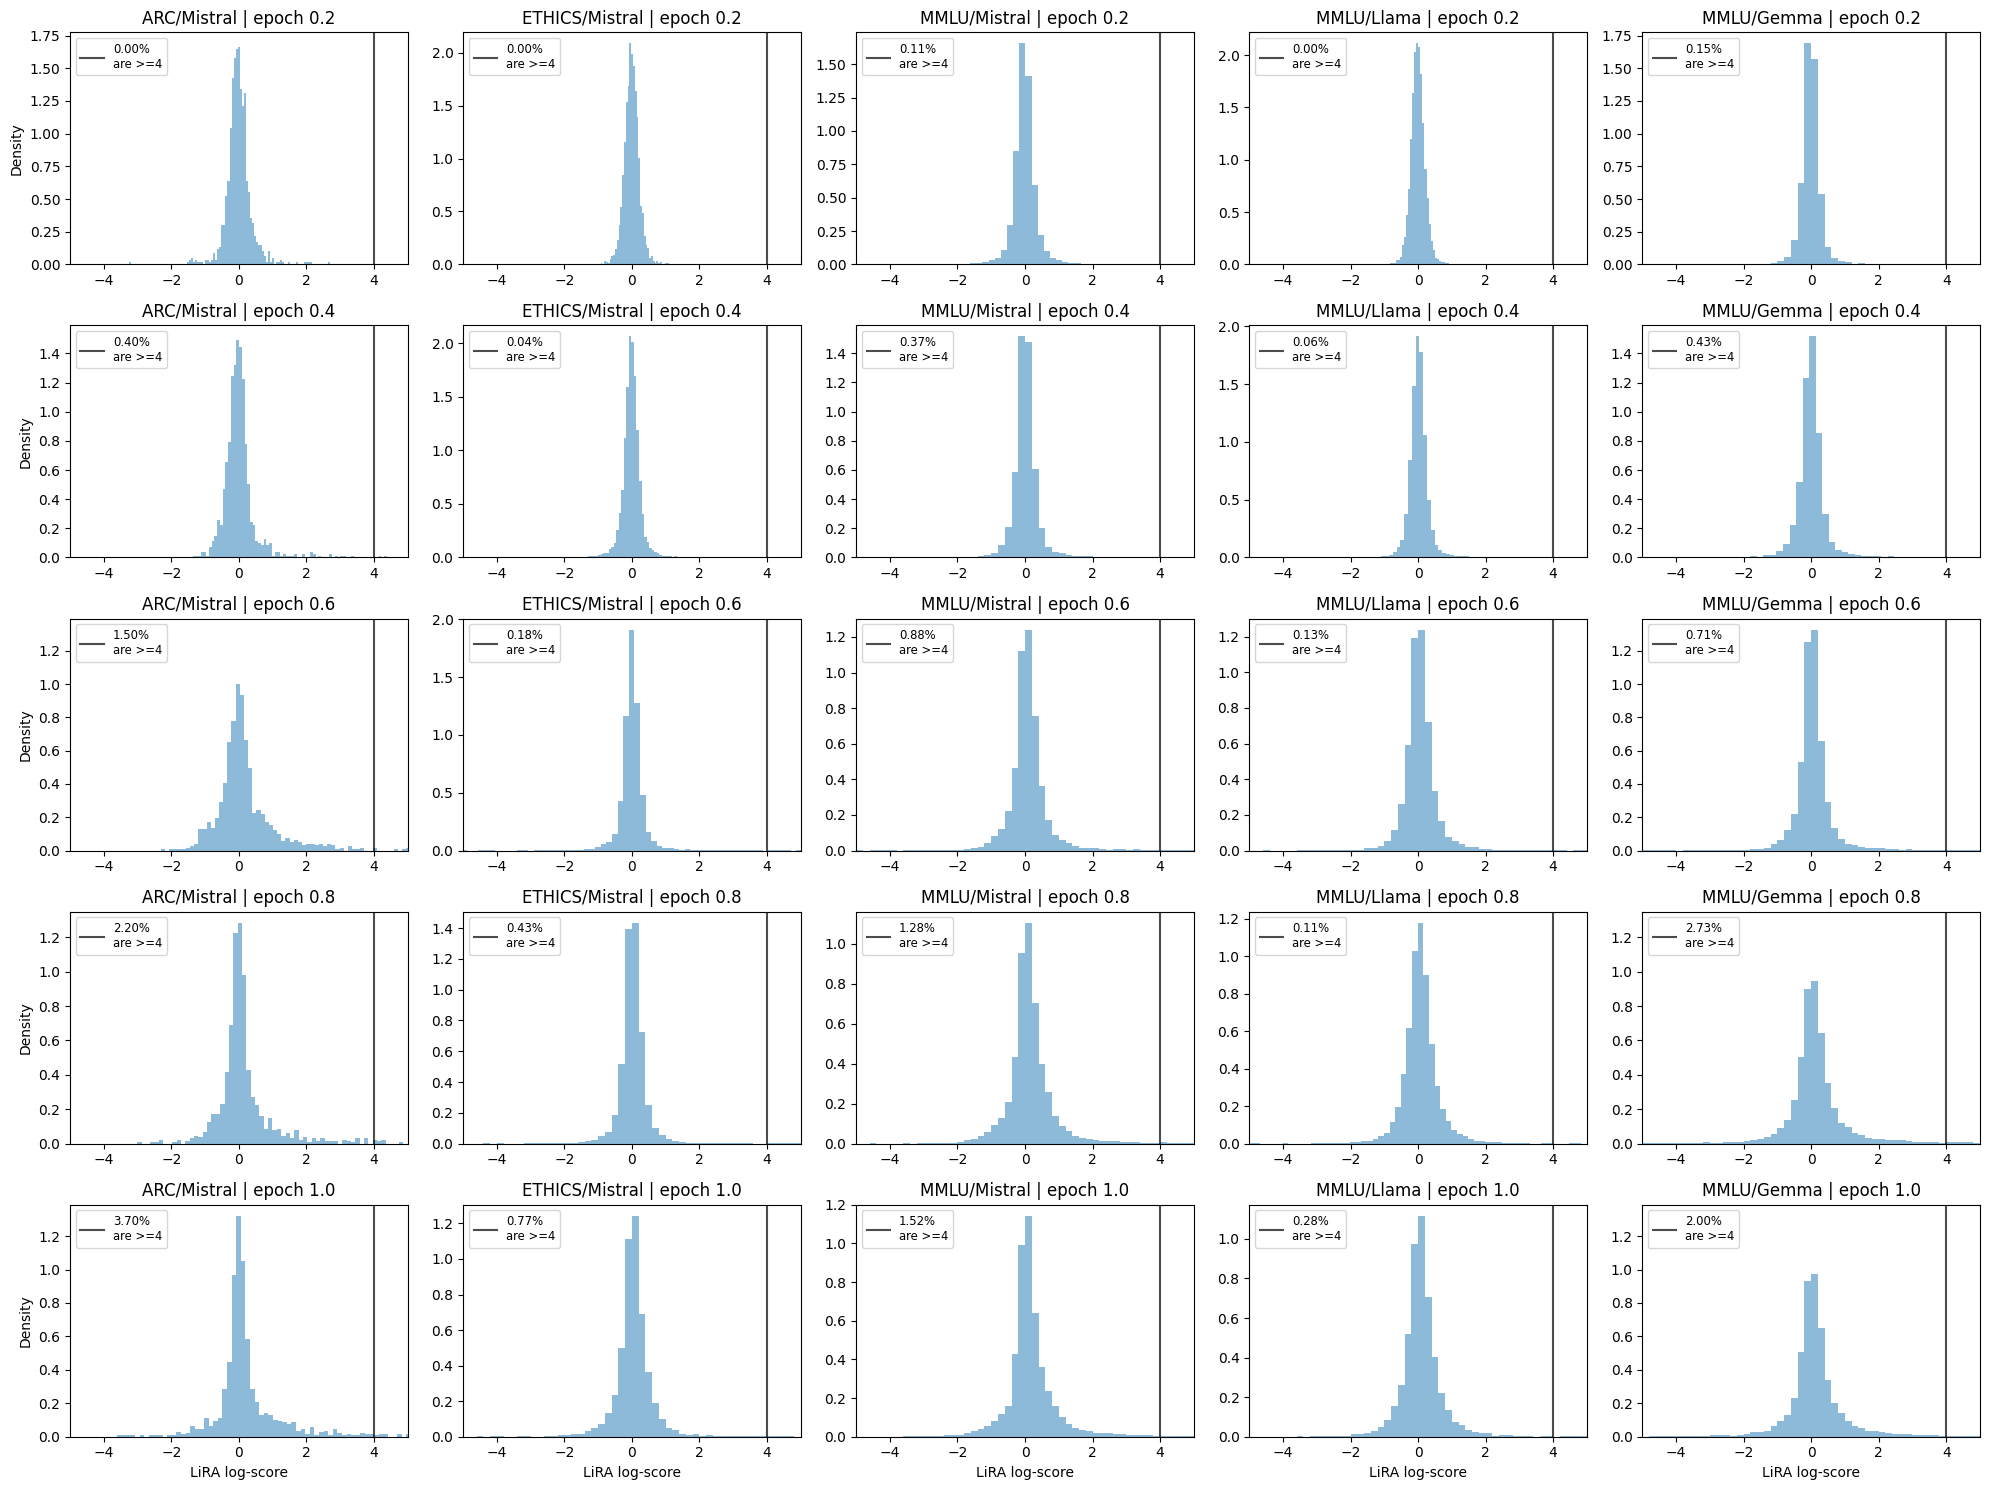

In [45]:
n_rows = len(checkpoints["mmlu_mis"])
n_cols = 5

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

for idx_col, setup in enumerate(setup_names):
    for idx_row, chk in enumerate(checkpoints[setup]):
        ax = axs[idx_row, idx_col]

        # Memo
        memo = np.array([memo_per_setup_per_chk_per_idx[setup][chk][idx] for idx in global_idx[setup]]).reshape(-1, 1)
        prop_memo = np.sum(memo >= HARD_MEMO_THD) / len(memo)

        # Plot
        ax.hist(memo, bins=BINS, density=True, alpha=.5, color=COLORS[0])
        ax.axvline(HARD_MEMO_THD, linestyle="-", label=f"{prop_memo:.2%}\nare >=4", color="black", alpha=.7)

        ax.set_title(f"{PRETTY_SETUP[setup]} | epoch {checkpoint_to_epoch[setup][chk]}")
        ax.set_xlim(MIN_X, MAX_X)
        ax.legend(loc="upper left", fontsize="small")

        if idx_row == n_rows - 1:
            ax.set_xlabel("LiRA log-score")
        if idx_col == 0:
            ax.set_ylabel("Density")
            ax.sharey(axs[idx_row, -1])

fig.tight_layout()
fig.savefig("appendix_memo_histograms.pdf")

## Appendix: quantiles

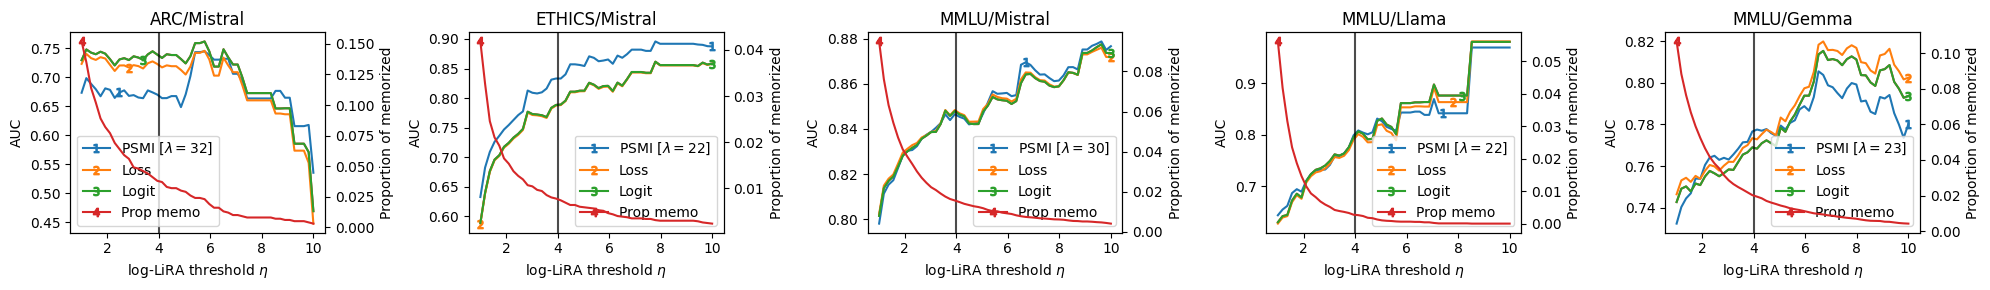

In [46]:

n_rows = 1
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
memo_thresholds = np.linspace(1, 10, endpoint=True, num=50)
marker_pos = [[8, 10, 13, 0],[49, 0, 49, 0],[31, 49, 49, 0],[35, 37, 39, 0],[49, 49, 49, 0]]

for idx_col, setup in enumerate(setup_names):

    ax = axes[idx_col]
    ax_prop = ax.twinx()

    # Checkpoints
    chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
    chk_memo = checkpoints[setup][-1]

    # Predictors
    predictors = {
        r"PSMI [$\lambda=$" + f"{BEST_FOR_PSMI[setup]}]": (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][BEST_FOR_PSMI[setup]][idx] for idx in global_idx[setup]],
            True,
        ),
        "Loss": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
        "Logit": (
            [logg_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            True,
        ),
    }

    # Iterating over predictors
    for idx_pred, (pred_name, (pred, reversed)) in enumerate(predictors.items()):
        memo = [memo_per_setup_per_chk_per_idx[setup][checkpoints[setup][INDEX_MEMO]][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Who is memorized ?
        quantile_hard_thd = sum(np.array(memo) >= HARD_MEMO_THD) / len(memo)
        
        fpr_at = []
        prop_memo = []
        for memo_thd in memo_thresholds:

            # memo_thd = np.quantile(memo, q=1-q)
            is_memorized = [item >= memo_thd for item in memo]

            # Prec-rec curve
            fpr, tpr, thd = roc_curve(is_memorized, pred, drop_intermediate=False)
            fpr_at.append(auc(fpr, tpr))
            prop_memo.append(sum(is_memorized) / len(is_memorized))

        # Plotting
        ax.plot(memo_thresholds, fpr_at, label=f"{pred_name}", marker=MARKERS[idx_pred], markevery=(marker_pos[idx_col][idx_pred], len(fpr_at)))
        if "Logit" in pred_name:
            ax_prop.plot(memo_thresholds, prop_memo, color=COLORS[3], marker=MARKERS[3], markevery=(marker_pos[idx_col][3], len(fpr_at)))

            # Fake PSMI to add a label
            ax.plot(memo_thresholds, fpr_at, label=f"Prop memo", color=COLORS[3], zorder=-1, marker=MARKERS[3], markevery=(len(fpr_at), len(fpr_at)))

    # Vline for hard threshold
    ax.axvline(4, label=None, color="black", alpha=.7)

    # Plotting details
    ax.legend()
    # ax.set_xscale("log")
    ax.set_xlabel(r"log-LiRA threshold $\eta$")
    ax.set_ylabel(f"AUC")
    ax_prop.set_ylabel("Proportion of memorized")
    ax.set_title(f"{PRETTY_SETUP[setup]}")

# Figure
fig.tight_layout()
fig.savefig("appendix_eta.pdf")


## Ablation : layers

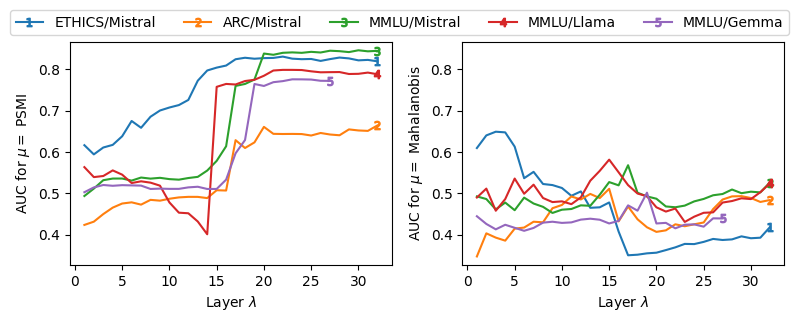

In [50]:
n_rows = 1
n_cols = 2

fig, (ax_psmi, ax_mahd) = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

vmin = 1
vmax = 0
for idx_setup, setup in enumerate(["ethi_mis", "arc__mis", "mmlu_mis", "mmlu_lla", "mmlu_gem"]):

    # Checkpoints
    chk_pred = checkpoints[setup][SETUP_TO_PRED_IDX[setup]]
    chk_memo = checkpoints[setup][-1]

    # Predictors
    predictors_psmi = {
        layer: (
            [p_smi_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][layer][idx] for idx in global_idx[setup]],
            True,
        )
        for layer in cfg[setup].all_layers
    } | {
        "LOSS": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
    }
    predictors_mahd = {
        layer: (
            [mahd_per_setup_per_chk_per_layer_per_idx[setup][chk_pred][layer][idx] for idx in global_idx[setup]],
            True,
        )
        for layer in cfg[setup].all_layers
    } | {
        "LOSS": (
            [loss_per_setup_per_chk_per_idx[setup][chk_pred][idx] for idx in global_idx[setup]],
            False,
        ),
    }

    # Iterating over predictors
    fpr_psmi_at_layer = {}
    fpr_mahd_at_layer = {}
    fpr_loss = None

    # Iterating: PSMI
    for pred_name, (pred, reversed) in predictors_psmi.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][chk_memo][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Who is memorized ?
        is_memorized = [item >= HARD_MEMO_THD for item in memo]

        # Prec-rec curve
        fpr, tpr, _ = roc_curve(is_memorized, pred, drop_intermediate=False)

        if type(pred_name) == int:
            fpr_psmi_at_layer[pred_name] = auc(fpr, tpr)
        elif "LOSS" in pred_name:
            fpr_loss = auc(fpr, tpr)
        
    # Iterating: MAHD
    for pred_name, (pred, reversed) in predictors_mahd.items():
        memo = [memo_per_setup_per_chk_per_idx[setup][chk_memo][idx] for idx in global_idx[setup]]
        if reversed:
            pred = [-1 * item for item in pred]
        
        # Sorting 
        sorting_index = sorted(range(len(pred)), key=lambda k: pred[k])
        nan_index = set([
            idx for idx in range(len(pred))
            if np.isnan(pred[idx]) or np.isnan(memo[idx]) or np.abs(pred[idx]) > 2**63
        ])
        memo = [memo[idx] for idx in sorting_index if idx not in nan_index]
        pred = [pred[idx] for idx in sorting_index if idx not in nan_index]

        # Who is memorized ?
        is_memorized = [item >= HARD_MEMO_THD for item in memo]

        # Prec-rec curve
        fpr, tpr, _ = roc_curve(is_memorized, pred, drop_intermediate=False)

        if type(pred_name) == int:
            fpr_mahd_at_layer[pred_name] = auc(fpr, tpr)

    # Values to plot
    layers = sorted(fpr_psmi_at_layer.keys())
    values_psmi = [fpr_psmi_at_layer[l] for l in layers]
    values_mahd = [fpr_mahd_at_layer[l] for l in layers]

    # Vmin and Vmax
    vmin = min(vmin, min(values_psmi))
    vmin = min(vmin, min(values_mahd))
    vmax = max(vmax, max(values_psmi))
    vmax = max(vmax, max(values_mahd))

    # Plotting - psmi
    ax_psmi.plot(layers, values_psmi, label=PRETTY_SETUP[setup], color=COLORS[idx_setup], marker=MARKERS[idx_setup], markevery=(len(layers)-1, len(layers)-1))
    # ax_psmi.plot(layers, [fpr_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup], marker=MARKERS[idx_setup], markevery=(0, len(layers)))

    # Plotting - zoom
    ax_mahd.plot(layers, values_mahd, color=COLORS[idx_setup], marker=MARKERS[idx_setup], markevery=(len(layers)-1, len(layers)-1))
    # ax_mahd.plot(layers, [fpr_loss for _ in layers], linestyle="--", alpha=.5, color=COLORS[idx_setup], marker=MARKERS[idx_setup], markevery=(0, len(layers)))

# Plotting details
ax_psmi.set_xlabel(r"Layer $\lambda$")
ax_psmi.set_ylabel(r"AUC for $\mu =$ PSMI")
ax_mahd.set_xlabel(r"Layer $\lambda$")
ax_mahd.set_ylabel(r"AUC for $\mu =$ Mahalanobis")

# Vmin, vmax
ax_psmi.set_ylim(vmin - 0.02, vmax + 0.02)
ax_mahd.set_ylim(vmin - 0.02, vmax + 0.02)

# Fig
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
fig.savefig("ablation_lambda.pdf", bbox_inches='tight')